In [2]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

In [3]:
#read the data
df = pd.read_pickle('data/dataset.pkl')
df.shape

(89774, 7)

In [5]:
#dictionary to map parties to num for tensors
party_dict={'SPÖ':0,'ÖVP':1,'FPÖ':2,'Grüne':3,'LIF':4,'BZÖ':5,'NEOS':6,'STRONACH':7,'PILZ':8,'independent':9}

df['speech_id'] = df.index
df['speech_id'] = df['speech_id'].astype(int)
independent_df= df[df['party']=='independent']
df = df[~(df['party']=='independent')]
df['party_name']= df['party']
df['party'] = df['party'].map(party_dict)
df['date_format']= pd.to_datetime(df['date'])
df.shape

(88219, 10)

In [6]:
df['party'].value_counts()

Series([], Name: party, dtype: int64)

In [7]:
def assign_gov(date):
    if date >= pd.Timestamp('1996-01-15') and date < pd.Timestamp('1999-10-29'):
        return 0
    elif date >= pd.Timestamp('1999-10-29') and date < pd.Timestamp('2002-12-20'):
        return 1
    elif date >= pd.Timestamp('2002-12-20') and date < pd.Timestamp('2006-10-30'):
        return 2
    elif date >= pd.Timestamp('2006-10-30') and date < pd.Timestamp('2008-10-28'):
        return 3 
    elif date >= pd.Timestamp('2008-10-28') and date < pd.Timestamp('2013-10-29'):
        return 4
    elif date >= pd.Timestamp('2013-10-29') and date < pd.Timestamp('2017-11-08'):
        return 5 
    elif date >= pd.Timestamp('2017-11-08') and date < pd.Timestamp('2019-10-22'):
        return 6
    else:
        return 7

In [8]:
fn="data/BERT_incl_independent.xlsx"
df= pd.read_excel(fn, index_col=0)

In [9]:
df['speaker'] = df['speaker'].replace(to_replace="Beate Hartinger$", value="Beate Hartinger-Klein", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Karin Miklautsch$", value= "Karin Gastinger", regex=True)
df['speaker'] = df['speaker'].replace(to_replace= "Helmut Moser$", value= "Hans Moser",regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Michael Pock$", value="Michael Bernhard", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Elisabeth Aumayr$", value= "Elisabeth Achatz", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Carmen Gartelgruber$", value= "Carmen Schimanek", regex=True)
df['speaker'] = df['speaker'].replace(to_replace="Sylvia Prettenthaler$", value= "Sylvia Rinner", regex=True)

In [10]:
df['date']= pd.to_datetime(df['date'])
df['gov'] = df['date'].map(assign_gov)
df= df.sort_values('date')
df = df.set_index('date')

In [11]:
#sp = df[df['party']==0]
#sp = sp.groupby(['predicted_party', 'gov']).size().unstack(fill_value=0)
#sp.to_excel('data/sp_misclassified_time.xlsx')
all_party_colors= ['#ff0000','#000000','#0066ff','#92d050','#ee7f00','#fecd00','#e84188','#a9a9a9','#ffff40','#efebdc']

In [12]:
def missclassified_plot(df,party,color,name):
    p_df=df[df['party']==party]
    p_df = p_df.groupby(['predicted_party', 'date']).size().unstack(fill_value=0)
    col_percentage = p_df.div(p_df.sum(axis=0), axis=1) * 100
    vis = col_percentage.T
    fig, ax = plt.subplots(figsize=(16, 5))
    monthly = vis.resample('Y').mean()
    ax.plot(monthly.index, monthly[0], color='#ff0000')
    ax.plot(monthly.index, monthly[1], color='#000000')
    ax.plot(monthly.index, monthly[2], color='#0066ff')
    ax.plot(monthly.index, monthly[3], color='#92d050')
    ax.plot(monthly.index, monthly[4], color='#ffff40')
    ax.plot(monthly.index, monthly[5], color='#ee7f00')
    ax.plot(monthly.index, monthly[6], color='#e84188')
    ax.plot(monthly.index, monthly[7], color='#fecd00')
    #ax.plot(monthly.index, monthly[8], color='#efebdc') #for BZÖ needs to be commented out
    #ax.plot(monthly.index, monthly[7], color='#fecd00')
    #ax.plot(monthly.index, monthly[6], color='#e84188')
    #ax.plot(monthly.index, monthly[5], color='#ee7f00')
    #ax.plot(monthly.index, monthly[4], color='#ffff40')
    #ax.plot(monthly.index, monthly[3], color='#92d050')
    #ax.plot(monthly.index, monthly[2], color='#0066ff')
    #ax.plot(monthly.index, monthly[1], color='#000000')
    #ax.plot(monthly.index, monthly[0], color='#ff0000')
    
    labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
    ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
    
    plt.axvspan(datetime(1996,1,15), datetime(1999, 10, 28), alpha=0.5, edgecolor=color,fill=False, facecolor=color, linewidth=1)
    plt.axvspan(datetime(2006,10,30), datetime(2017, 11, 8), alpha=0.5, edgecolor=color,fill=False, linewidth=1)
    #plt.axvspan(datetime(2006,4,28), datetime(2006, 10, 29), alpha=0.5, edgecolor='orange',fill=True, linewidth=1)#timespan for BZÖ foundation
    plt.title(('Distribution of the classification of {} speeches').format(name))
    

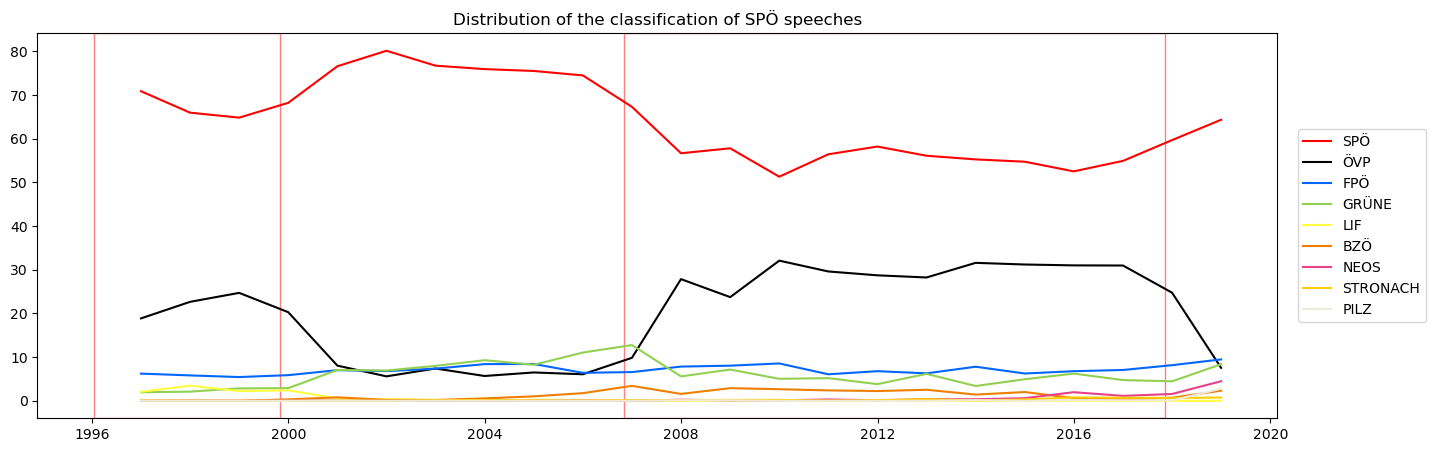

In [29]:
missclassified_plot(df,0,'red','SPÖ')

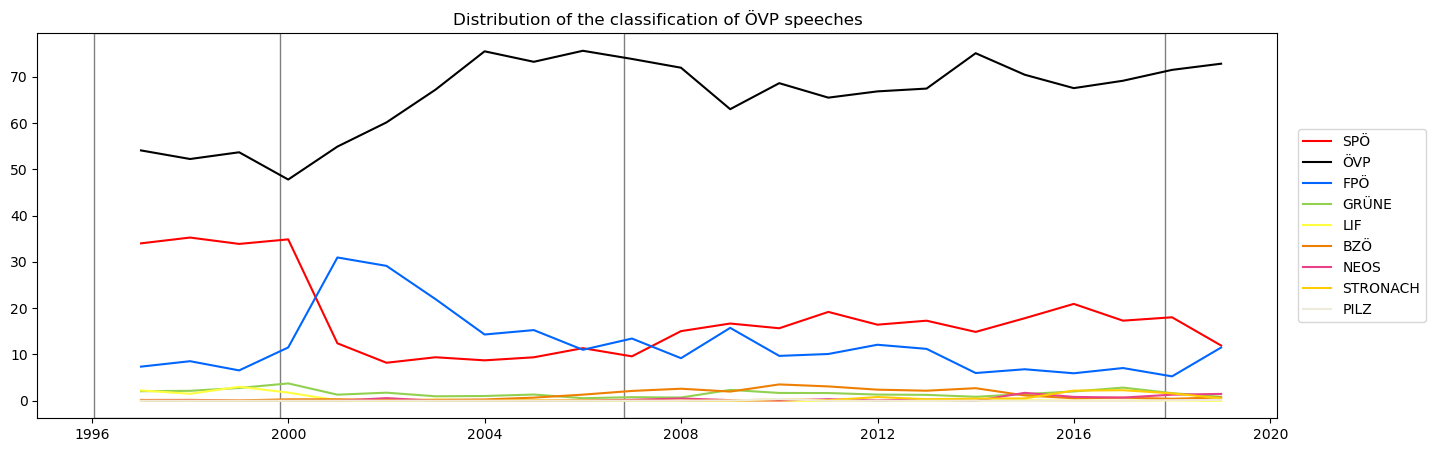

In [30]:
missclassified_plot(df,1,'black','ÖVP')

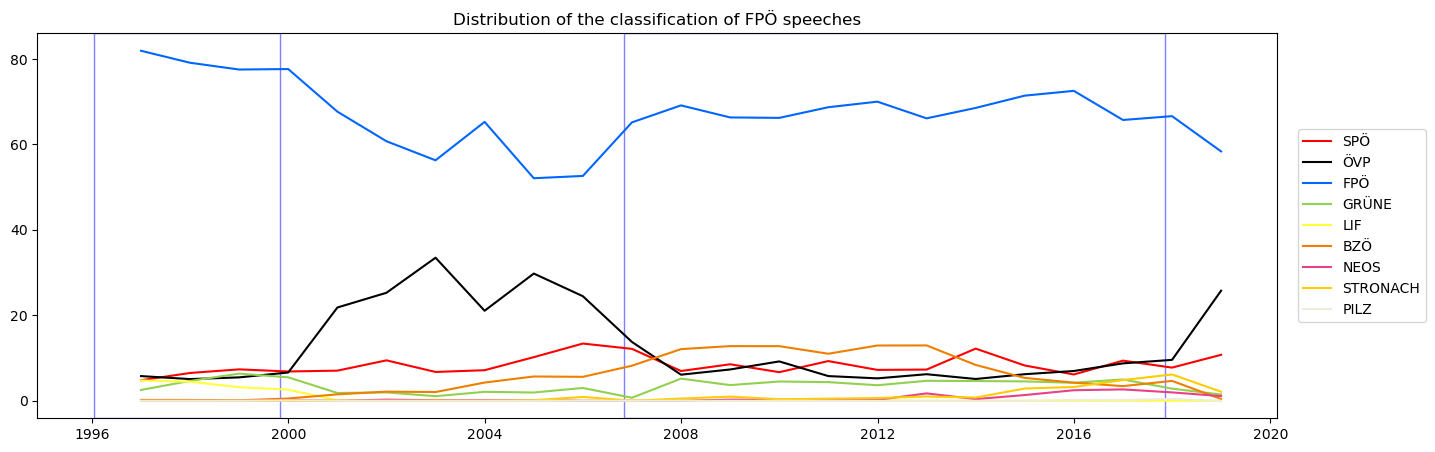

In [31]:
missclassified_plot(df,2,'blue','FPÖ')

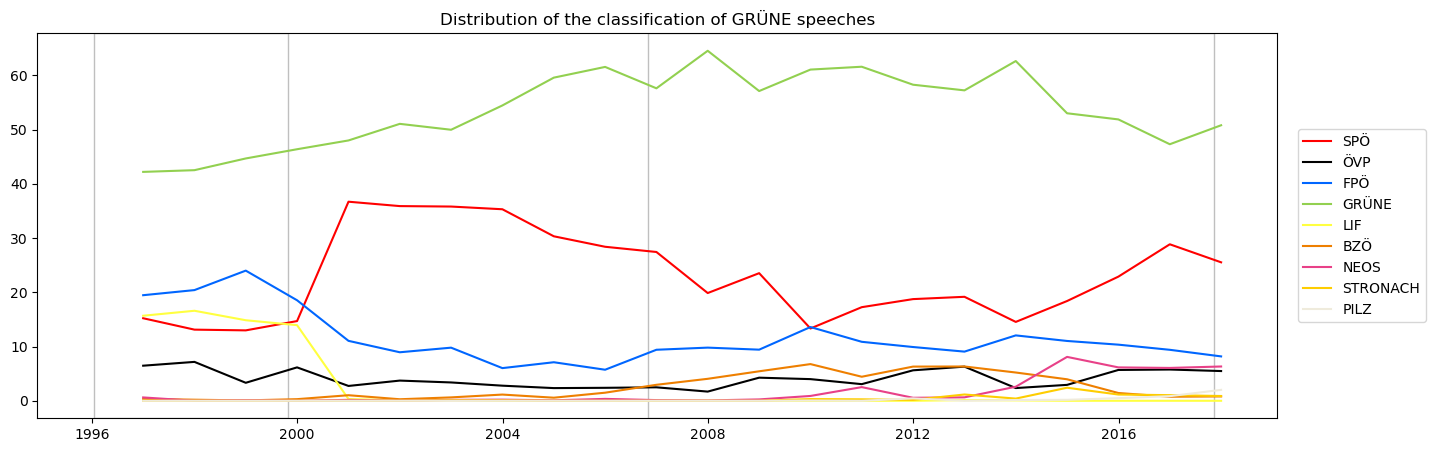

In [32]:
missclassified_plot(df,3,'grey','GRÜNE')

In [22]:
#vp = df[df['party']==1]
#vp = vp.groupby(['predicted_party', 'gov']).size().unstack(fill_value=0)
#vp.to_excel('data/vp_misclassified_time.xlsx')

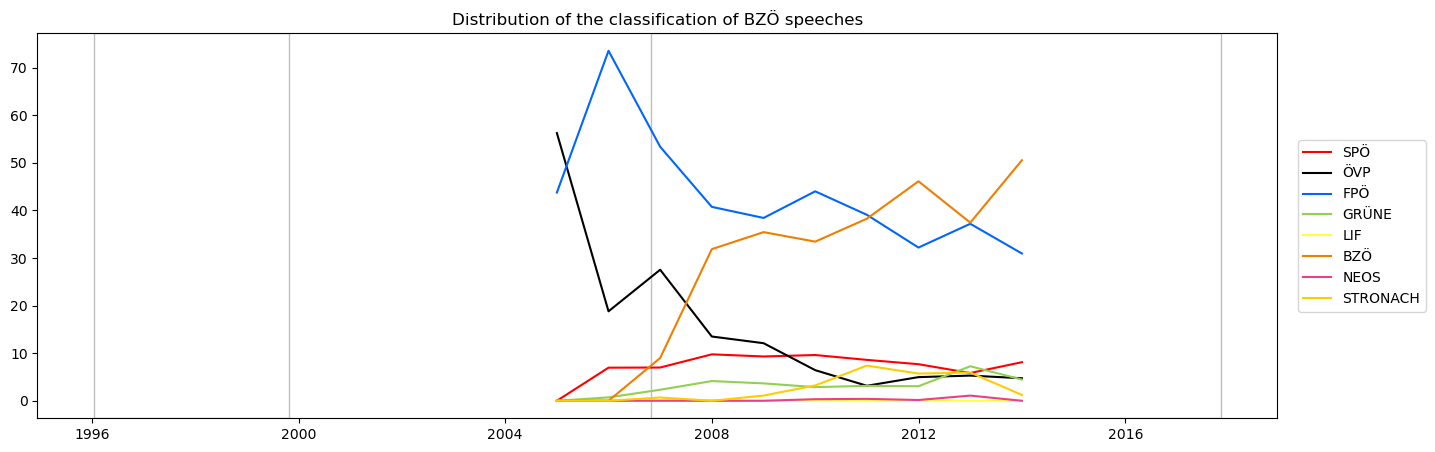

In [35]:
missclassified_plot(df,5,'grey','BZÖ')

In [23]:
#fp = df[df['party']==2]
#fp = fp.groupby(['predicted_party', 'gov']).size().unstack(fill_value=0)
#fp.to_excel('data/fp_misclassified_time.xlsx')

In [24]:
#gr = df[df['party']==3]
#gr = gr.groupby(['predicted_party', 'gov']).size().unstack(fill_value=0)
#gr.to_excel('data/gr_misclassified_time.xlsx')

In [38]:
df5= df[(df['party']==5)]
df2= df[(df['party']==2)]
print(df5['party'].value_counts())
print(df2['party'].value_counts())

5    4170
Name: party, dtype: int64
2    17308
Name: party, dtype: int64


In [13]:
party_colour_dict_name= {
    'SPÖ':'#ff0000',
    'ÖVP':'#000000',
    'FPÖ':'#0066ff',
    'Grüne':'#92d050',
    'LIF':'#ffff40',
    'BZÖ':'#ee7f00',
    'NEOS':'#e84188',
    'STRONACH':'#fecd00',
    'PILZ':'#efebdc'
}
party_colour_dict= {
    0:'#ff0000',
    1:'#000000',
    2:'#0066ff',
    3:'#92d050',
    4:'#ffff40',
    5:'#ee7f00',
    6:'#e84188',
    7:'#fecd00',
    8:'#efebdc'
}

party_dict_name= {
    0:'SPÖ',
    1:'ÖVP',
    2:'FPÖ',
    3:'Grüne',
    4:'LIF',
    5:'BZÖ',
    6:'NEOS',
    7:'STRONACH',
    8:'PILZ'
}

In [14]:
def create_graph_mp(mp, df,party1,party2,y,m,d):#,y,m,d #color1, color2
    
    colour1=party_colour_dict.get(party1,'grey')
    colour2=party_colour_dict.get(party2,'grey')
    mp_df=df[df['speaker']==mp]
    print(mp_df.shape)
    fig, ax = plt.subplots(figsize=(16, 5))
    
    dayly = mp_df.resample('y').mean()
    ax.plot(dayly.index, dayly[party1], color=colour1)
    ax.plot(dayly.index, dayly[party2], color=colour2)
    #plt.plot(mp_df.index, mp_df[party1], color= colour1)
    #plt.plot(mp_df.index, mp_df[party2], color= colour2)
    
    labels=[]
    labels.append(party_dict_name.get(party1))
    labels.append(party_dict_name.get(party2))
    
    ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
    
    plt.title(mp)
    plt.axvline(datetime(y,m,d), color=colour1)
    #plt.axvspan(datetime(2005,4,28), datetime(2006, 6, 28), alpha=0.5, edgecolor=colour2, linewidth=5)

(62, 18)
(9, 18)
(170, 18)
(83, 18)
(124, 18)
(26, 18)
(89, 18)
(65, 18)
(340, 18)
(88, 18)
(57, 18)


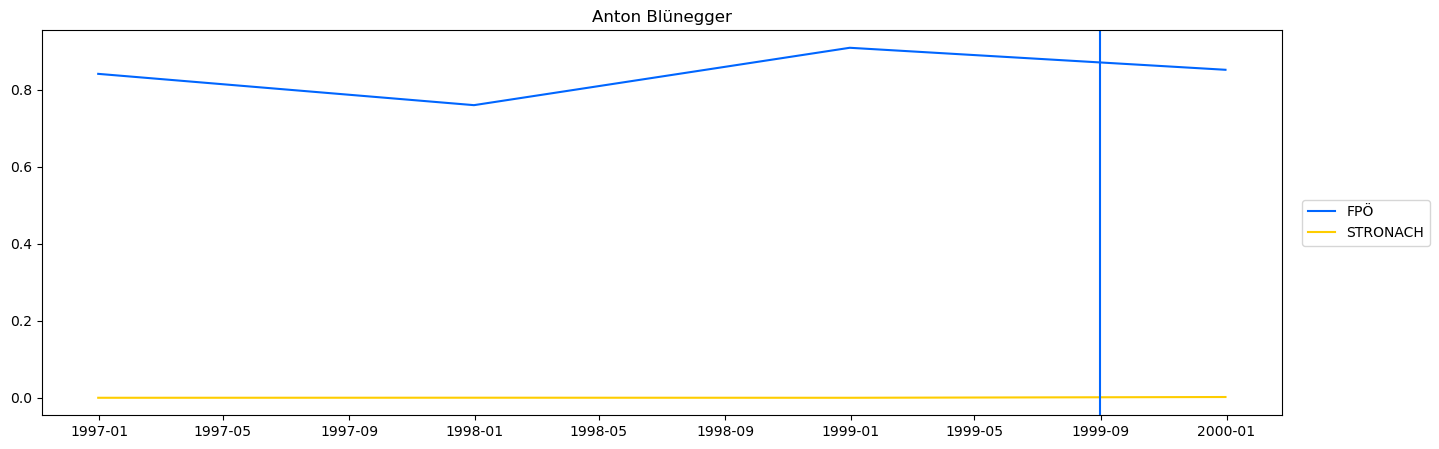

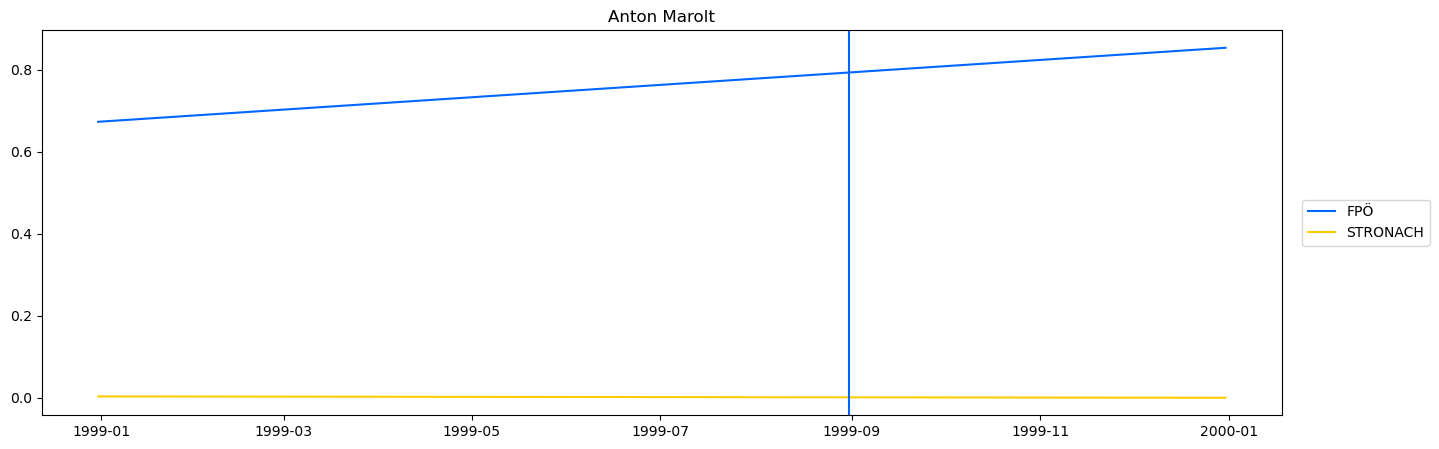

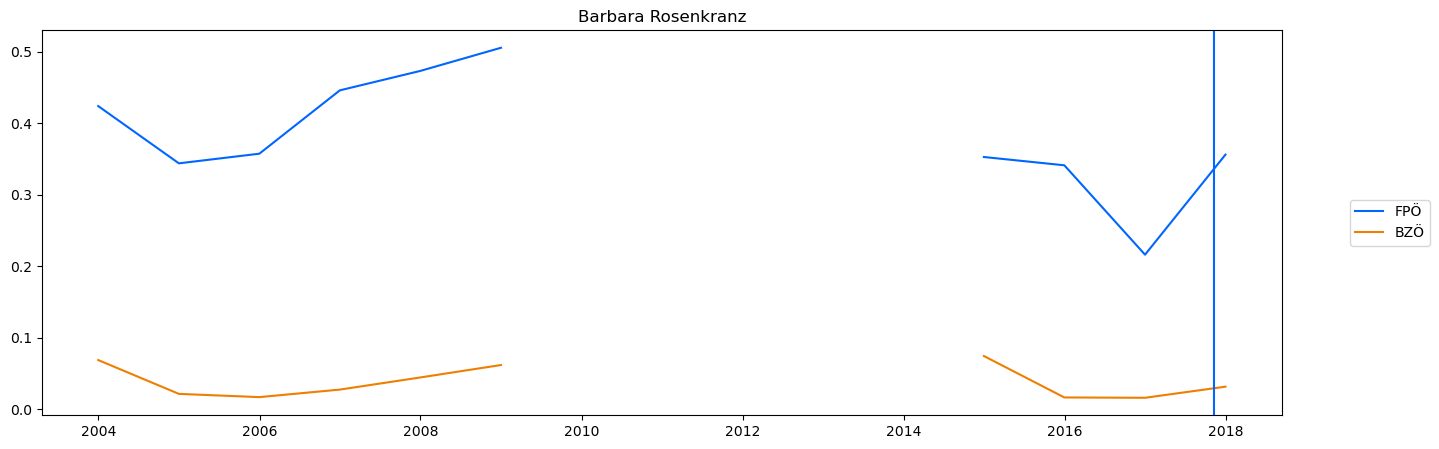

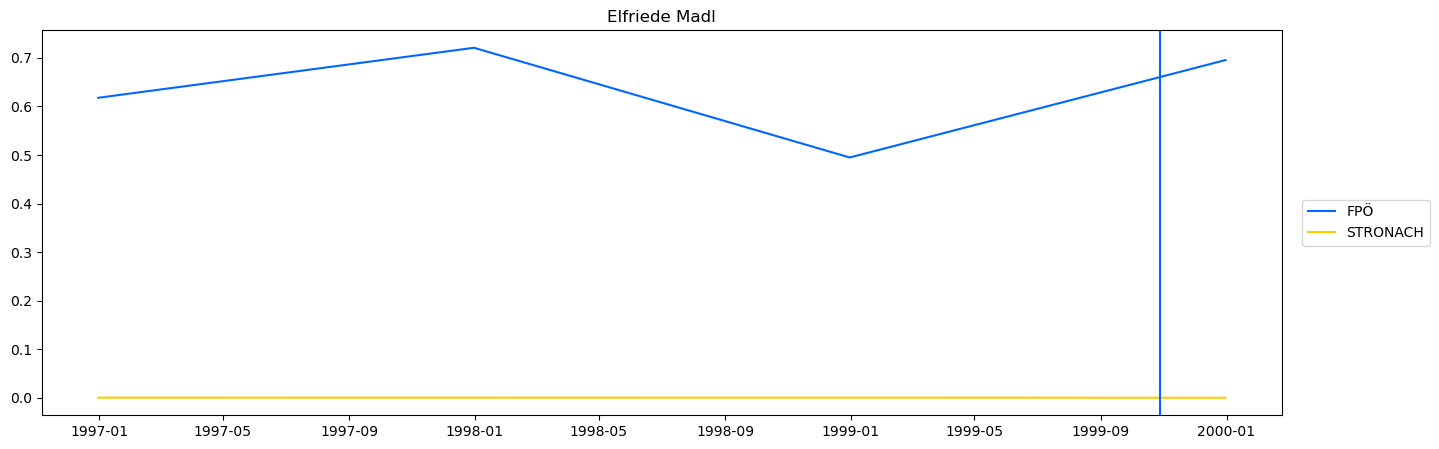

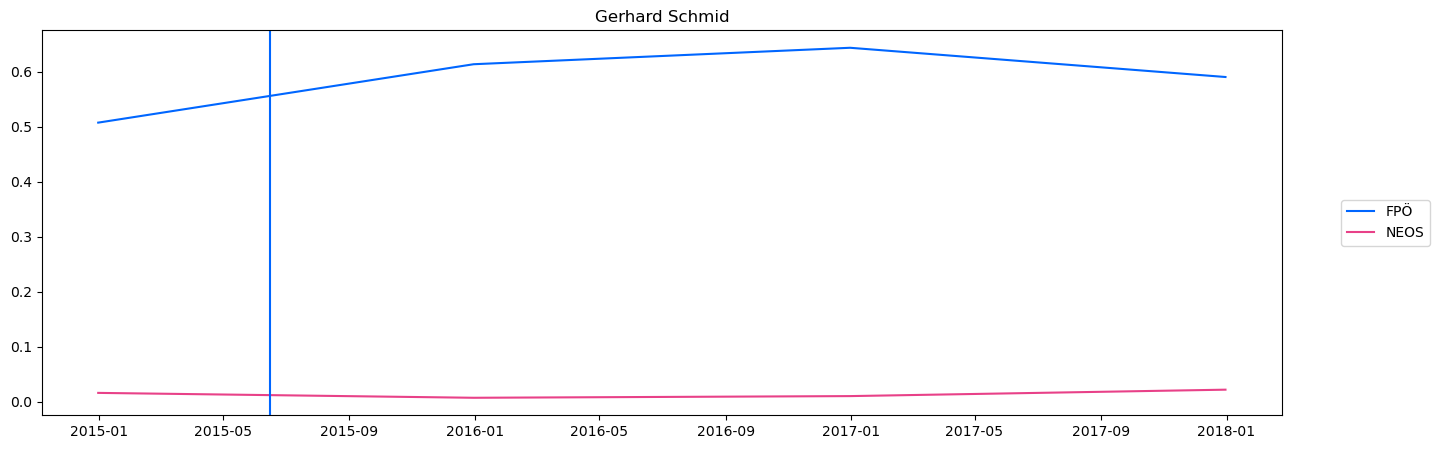

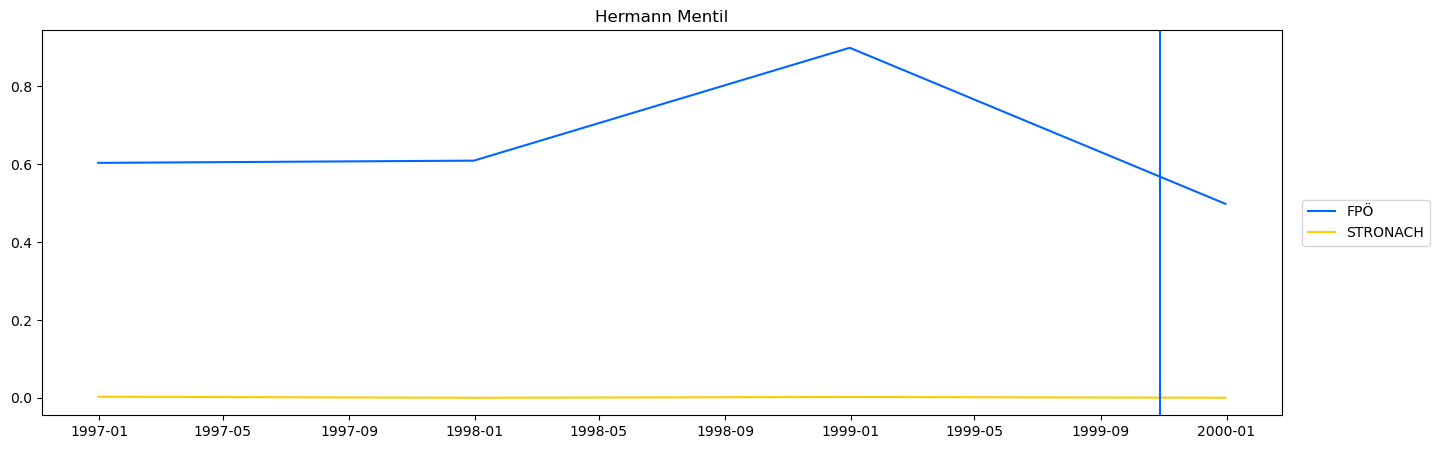

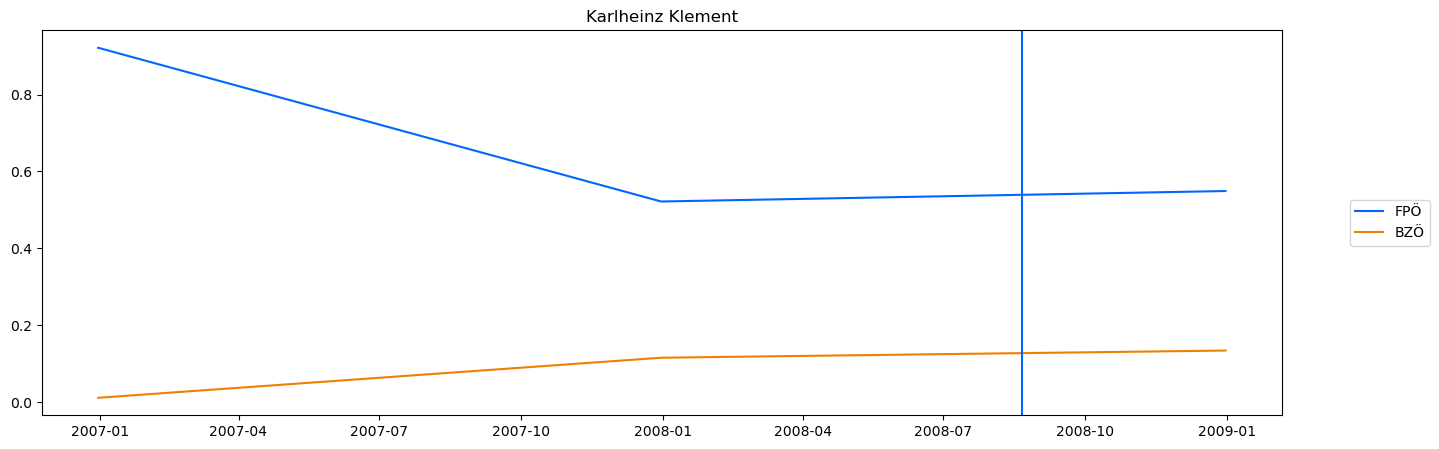

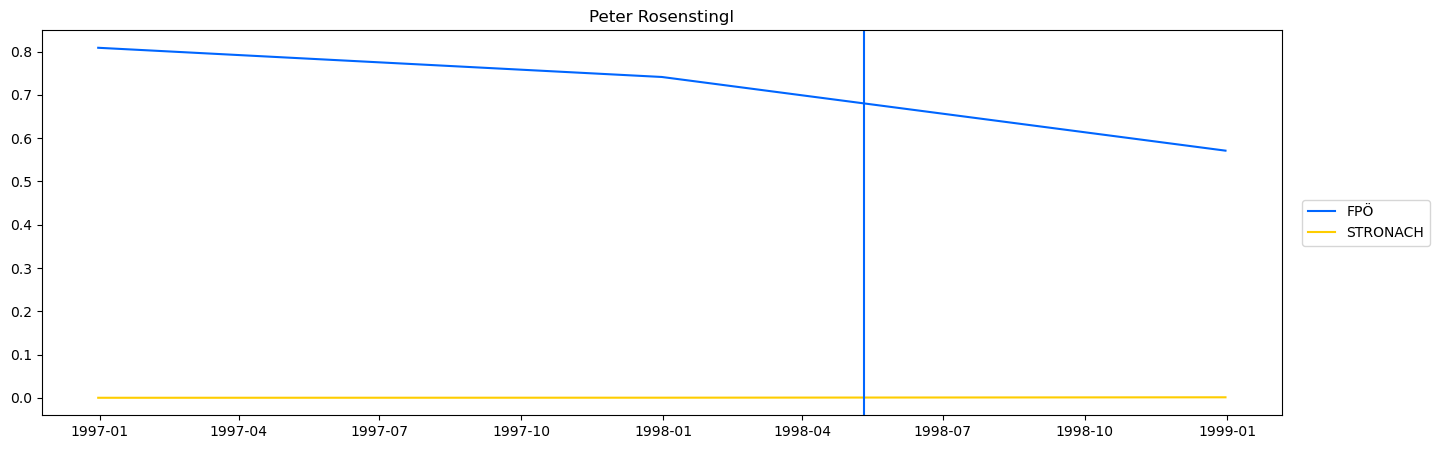

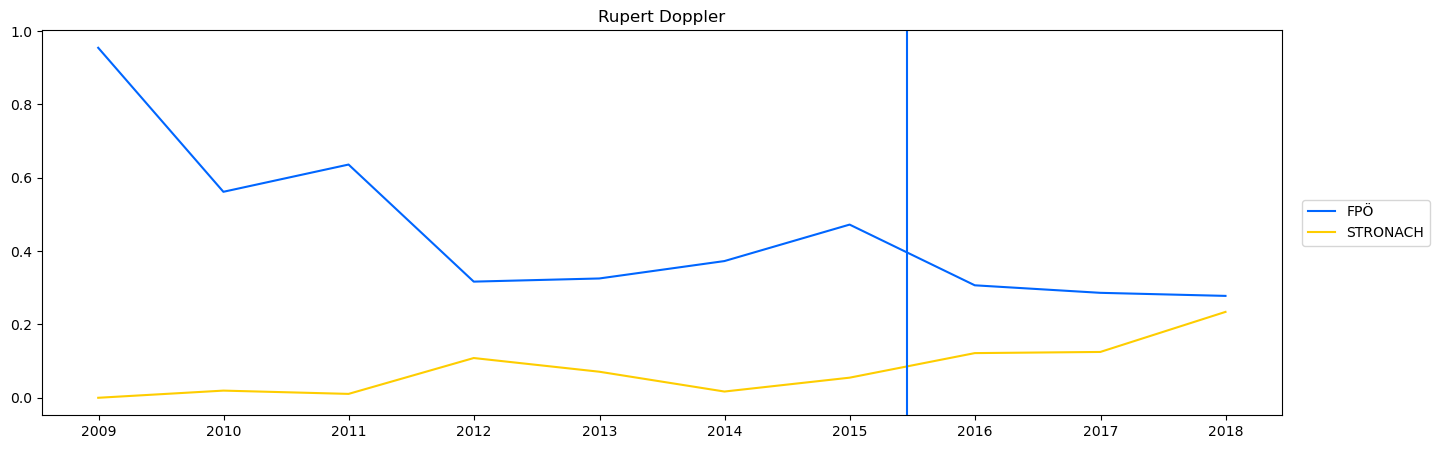

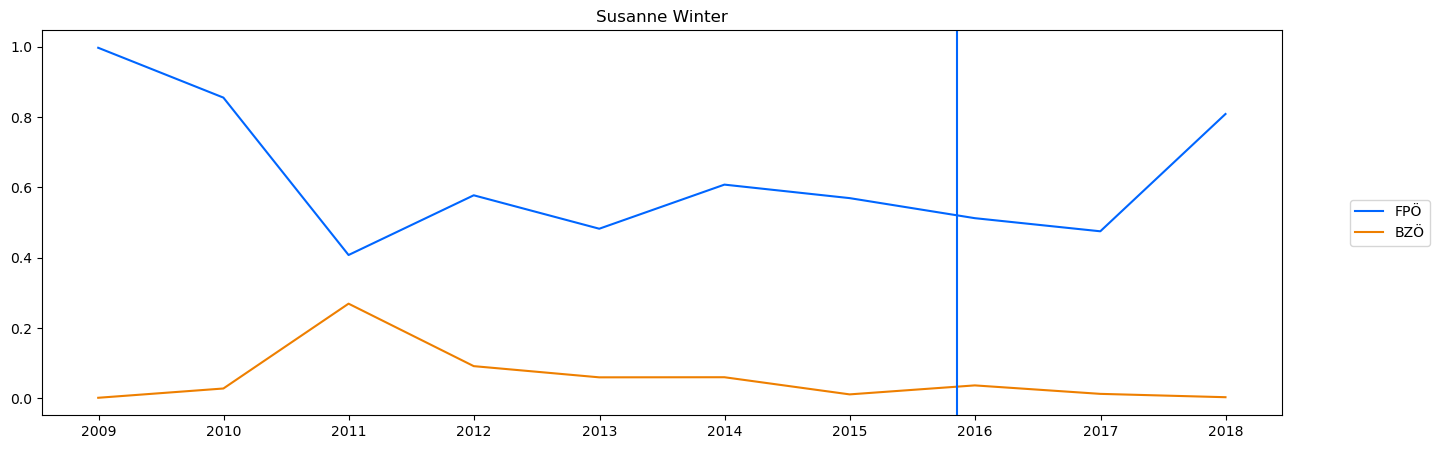

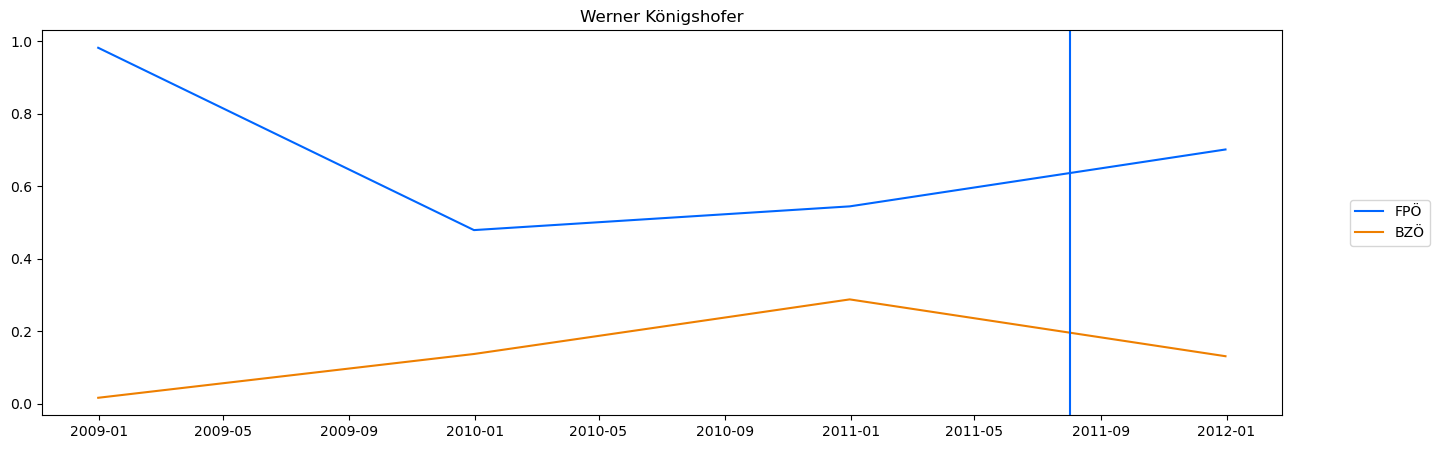

In [60]:
'''MPs that left the FPÖ and became indepenendent'''

create_graph_mp('Anton Blünegger', df, 2, 7, 1999,8,31)
create_graph_mp('Anton Marolt', df, 2, 7, 1999,8,31)
create_graph_mp('Barbara Rosenkranz', df, 2, 5, 2017,11,8)
create_graph_mp('Elfriede Madl', df, 2, 7, 1999,10,28)
create_graph_mp("Gerhard Schmid", df, 2, 6, 2015,6,16)
create_graph_mp('Hermann Mentil', df, 2, 7, 1999,10,28)
create_graph_mp('Karlheinz Klement', df, 2, 5, 2008,8,21)
create_graph_mp('Peter Rosenstingl', df,2, 7, 1998,5,11)
create_graph_mp('Rupert Doppler', df,2, 7, 2015,6,16)
create_graph_mp('Susanne Winter', df,2, 5, 2015,11,10)
create_graph_mp('Werner Königshofer', df, 2, 5, 2011,8,2)

(66, 18)
(408, 18)
(52, 18)
(66, 18)
(131, 18)
(561, 18)
(198, 18)
(947, 18)
(444, 18)
(89, 18)
(192, 18)
(109, 18)
(154, 18)
(29, 18)
(81, 18)
(131, 18)
(159, 18)
(142, 18)
(464, 18)
(431, 18)
(524, 18)
(54, 18)
(363, 18)


C:\Users\sarah\AppData\Local\Temp\ipykernel_12780\3154810208.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16, 5))


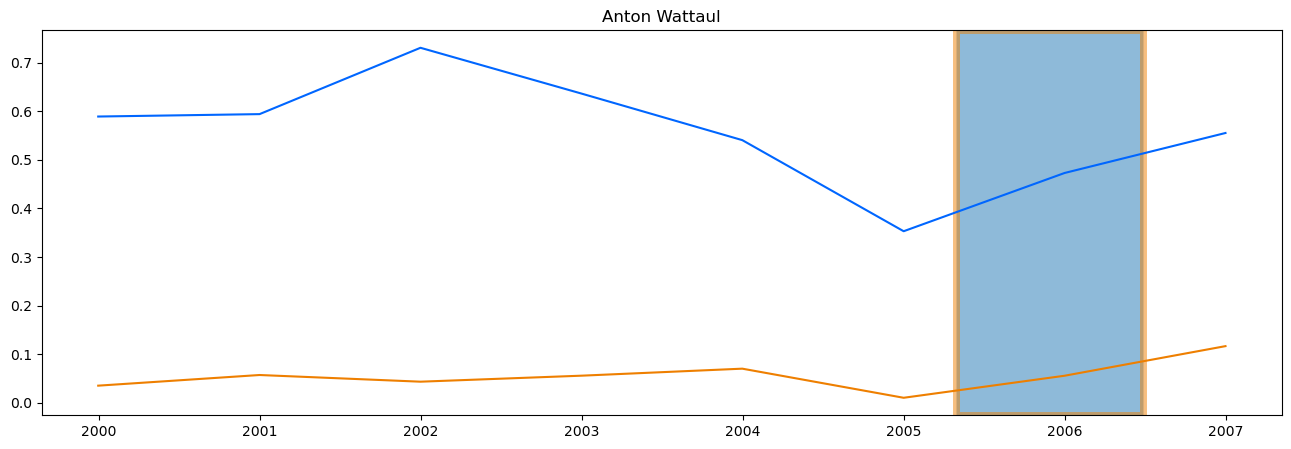

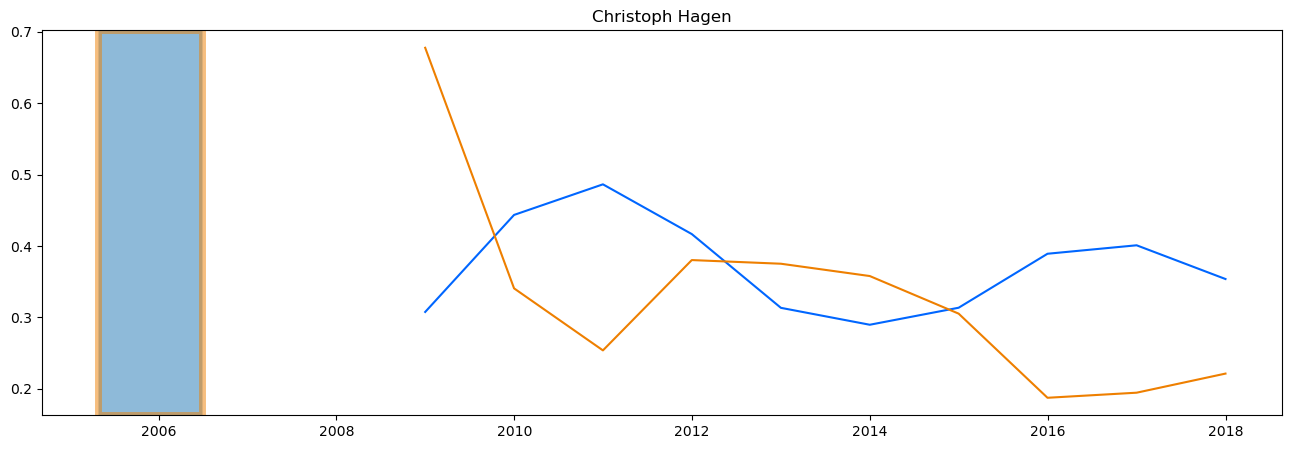

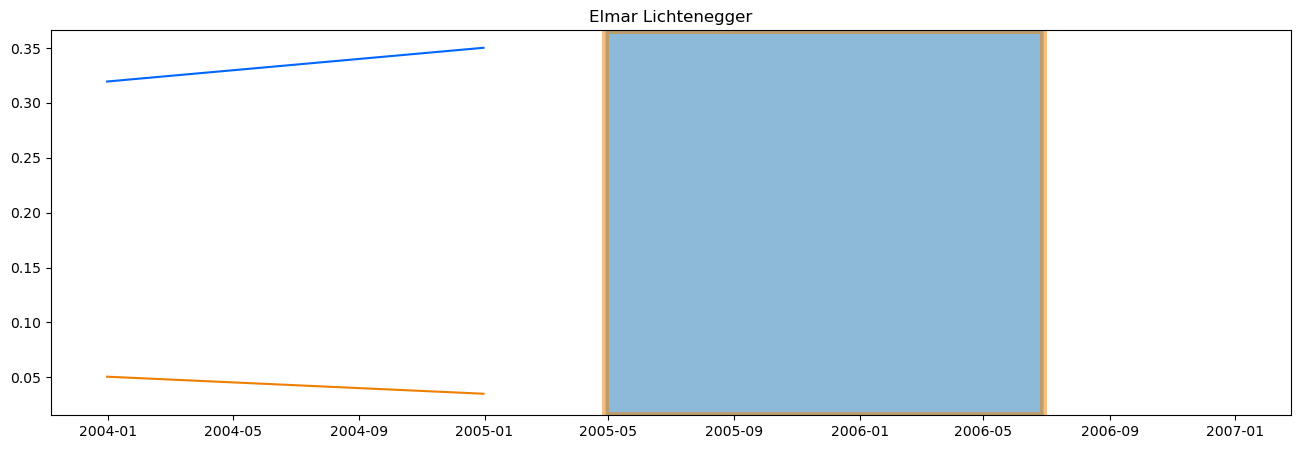

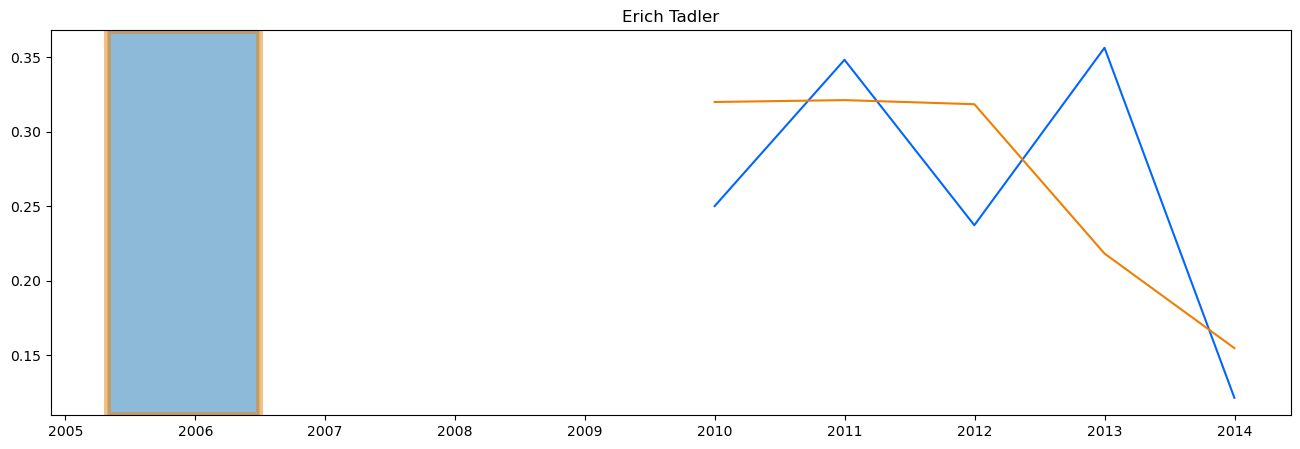

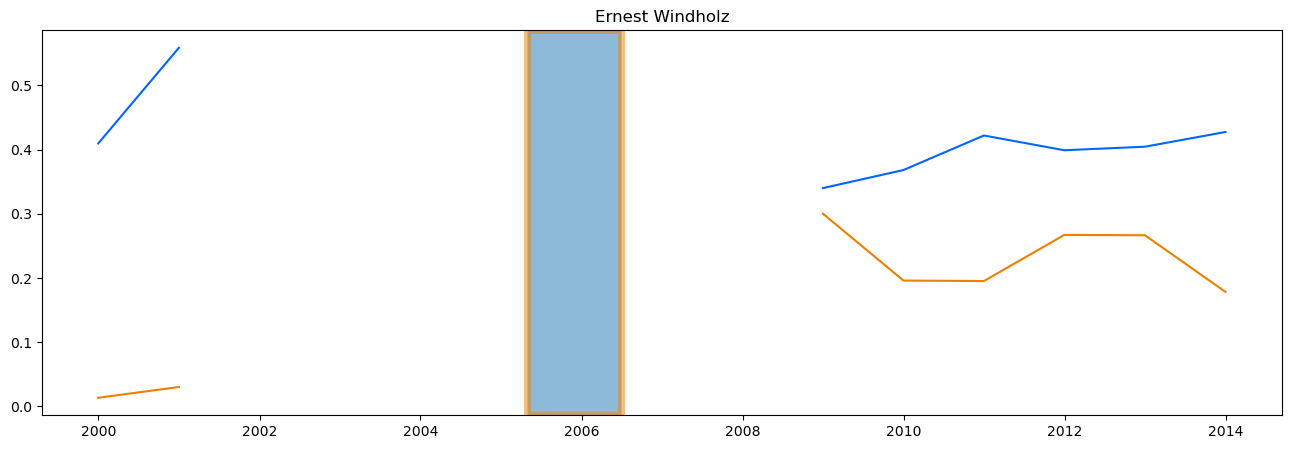

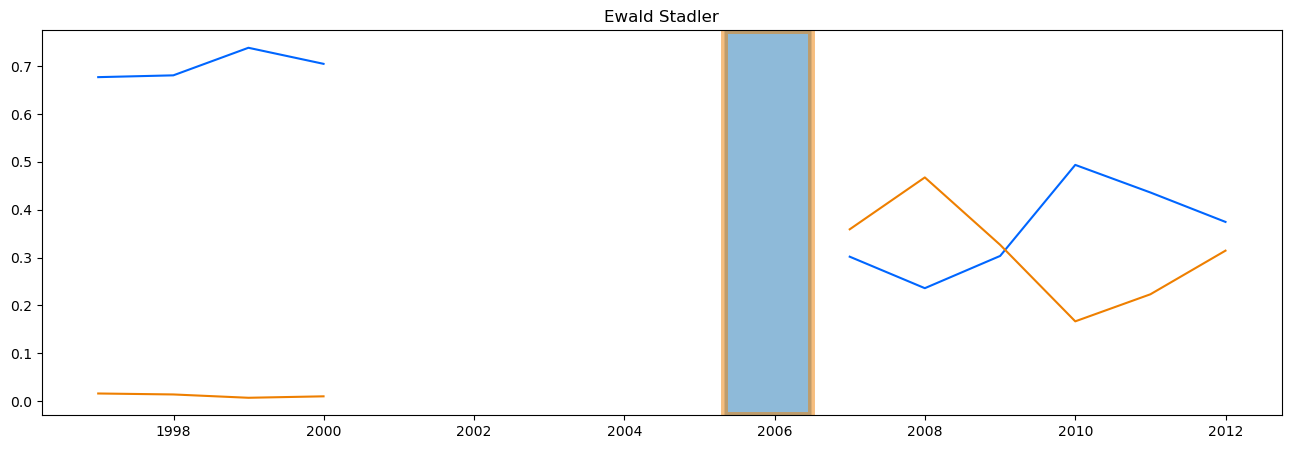

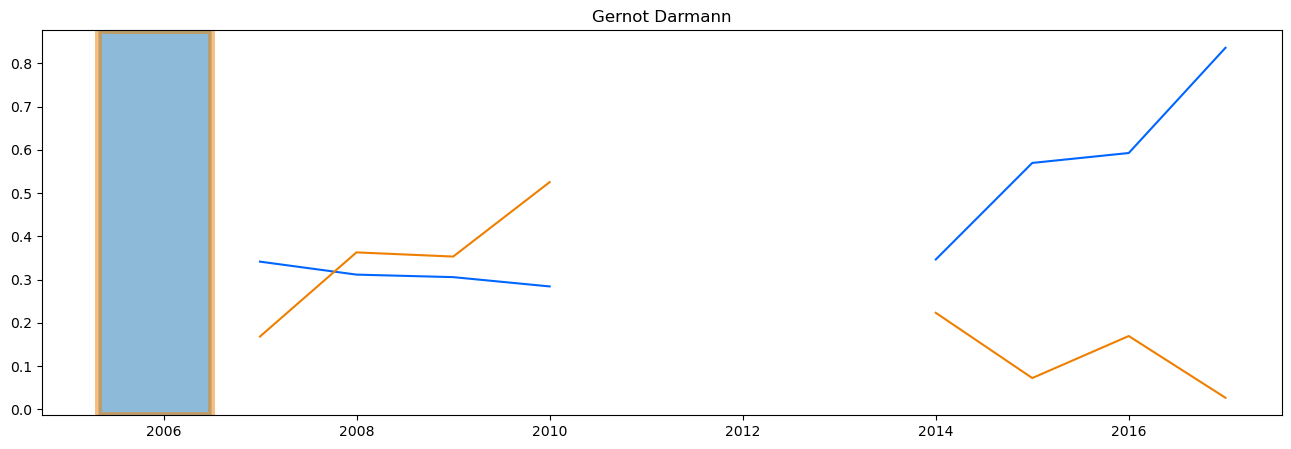

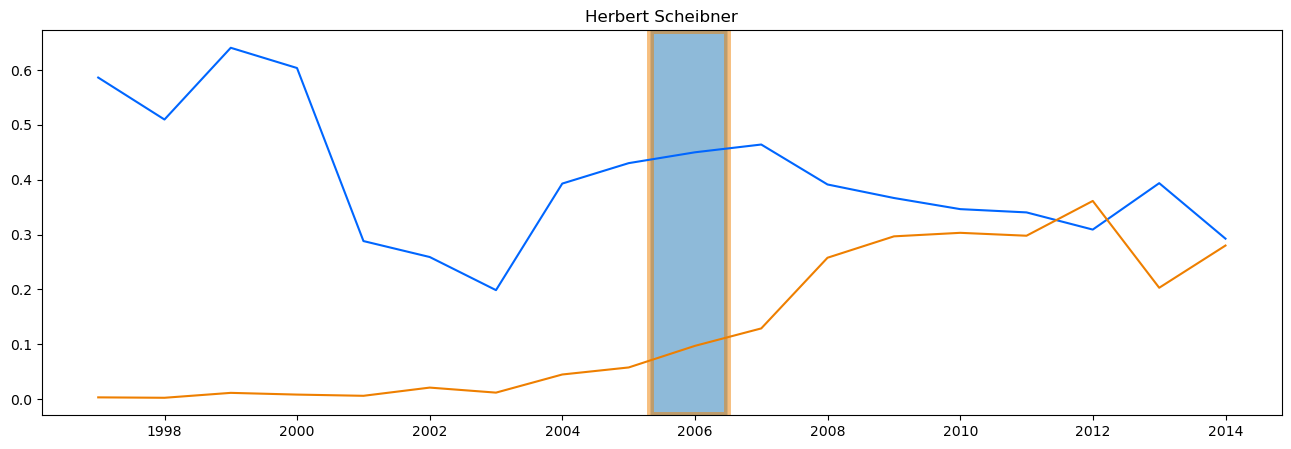

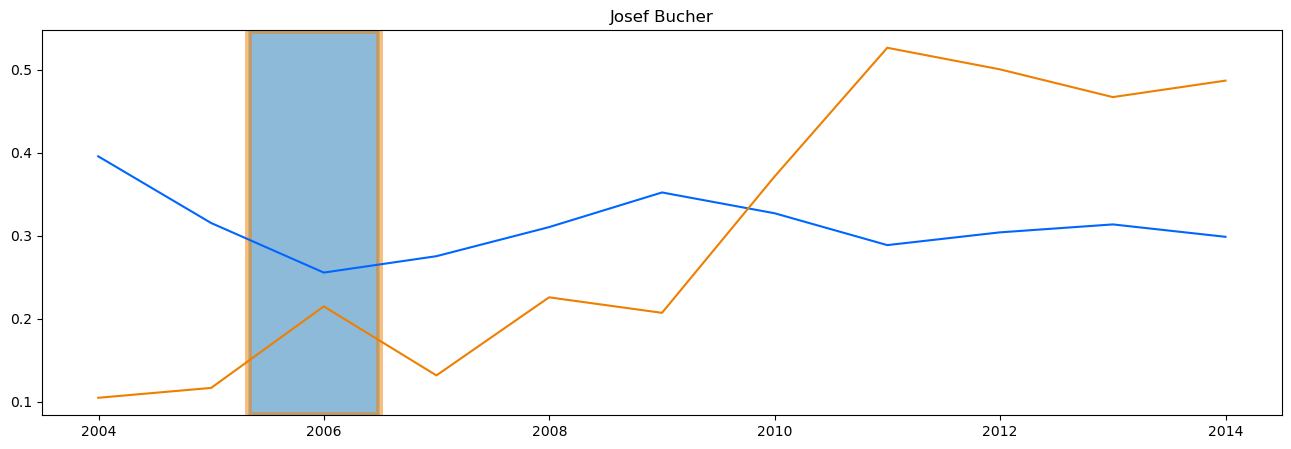

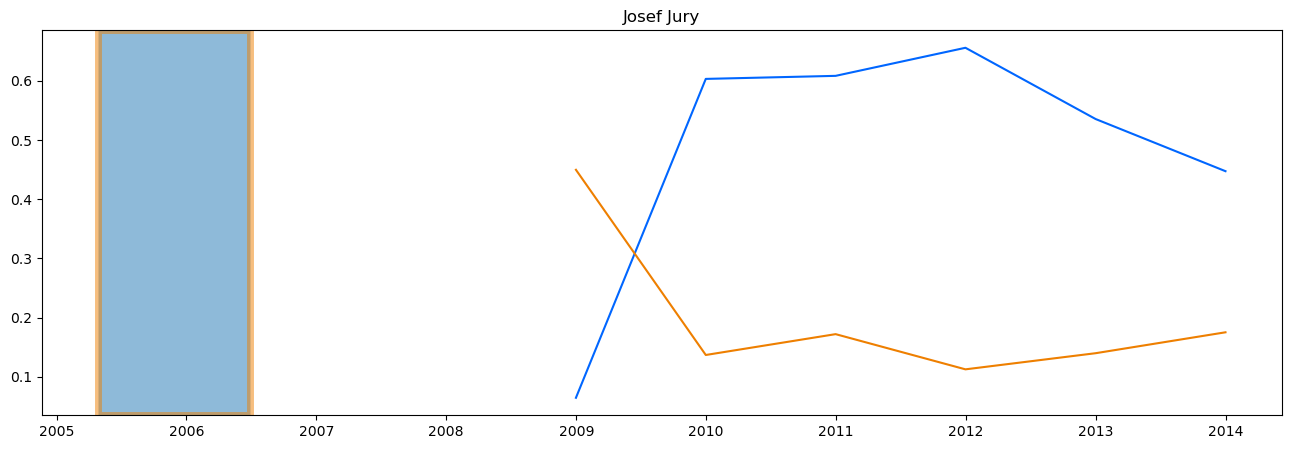

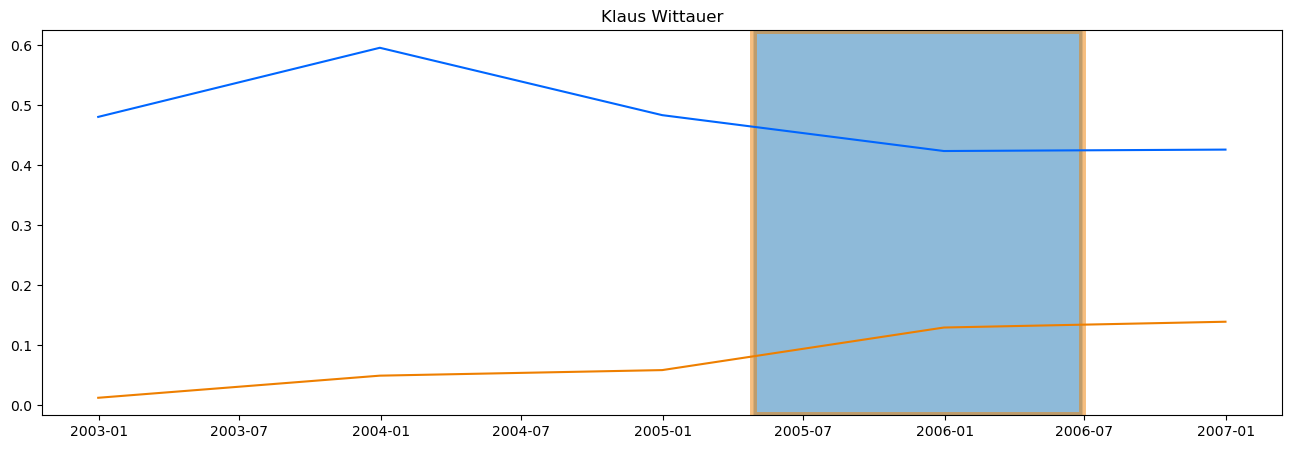

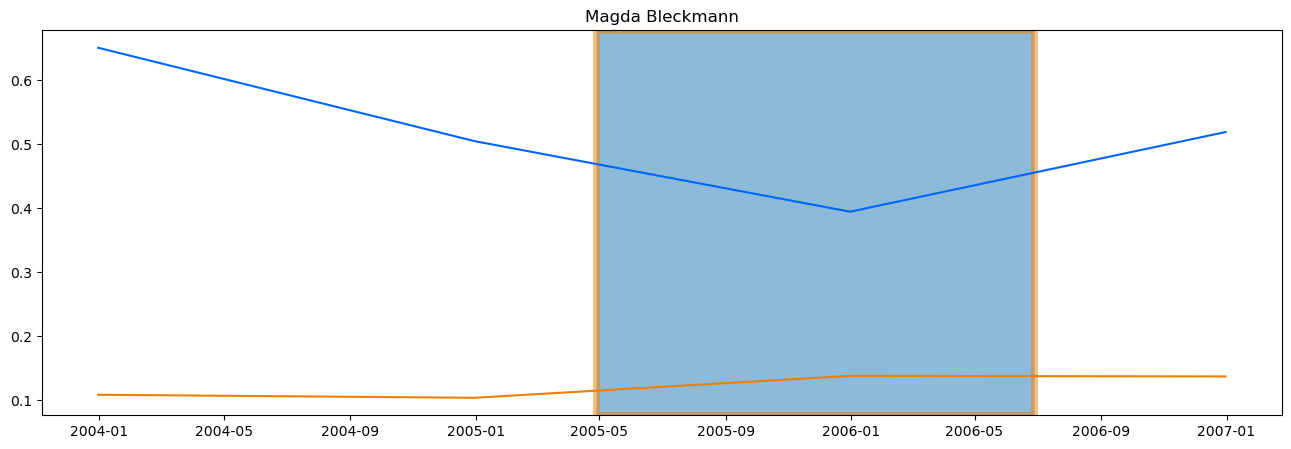

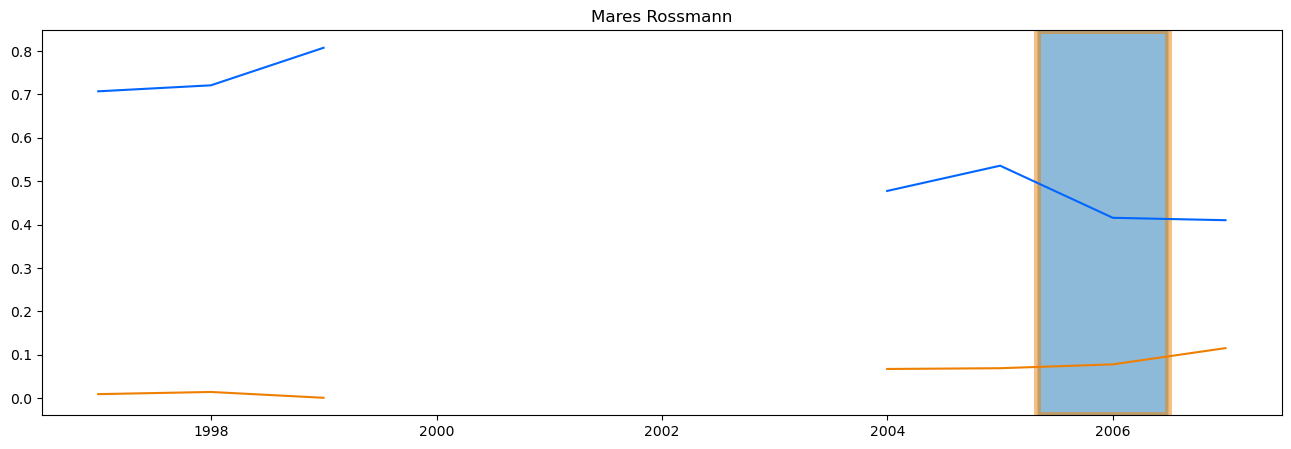

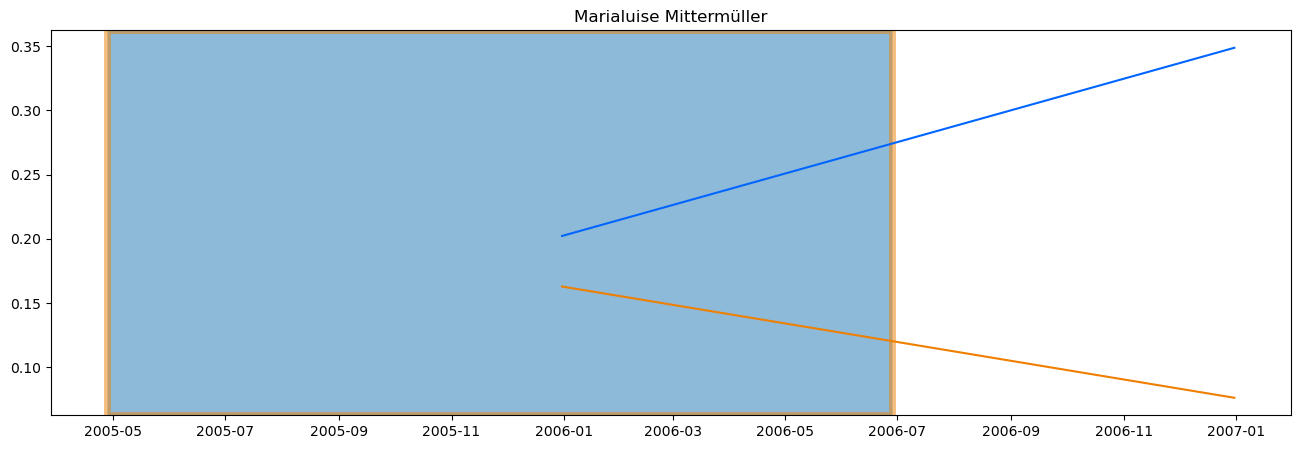

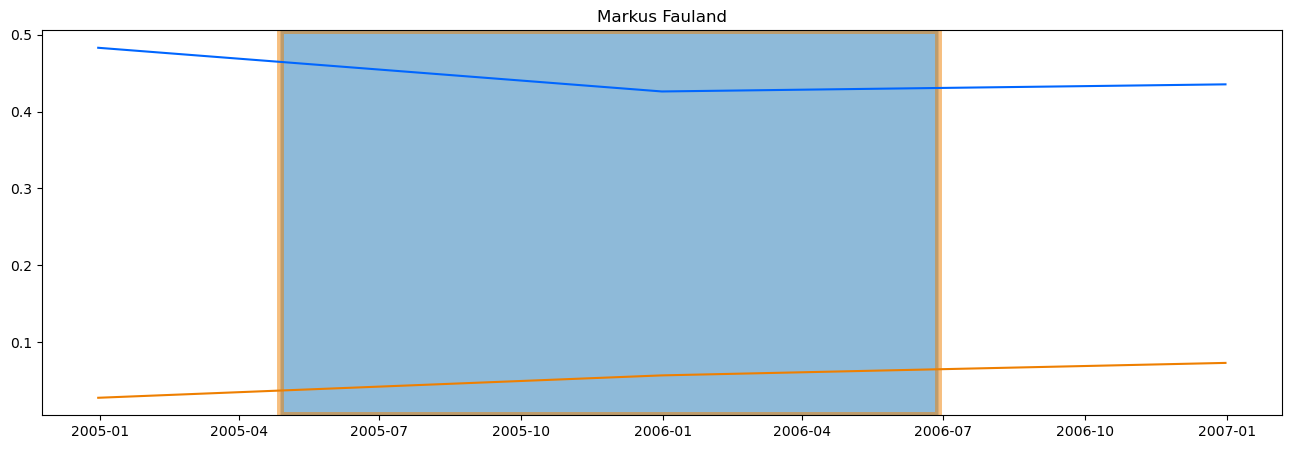

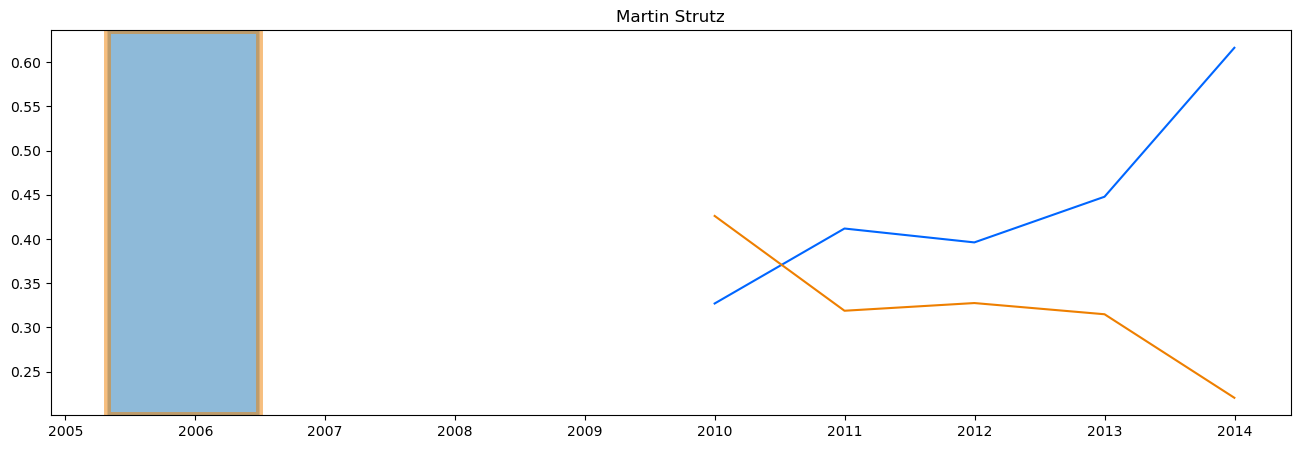

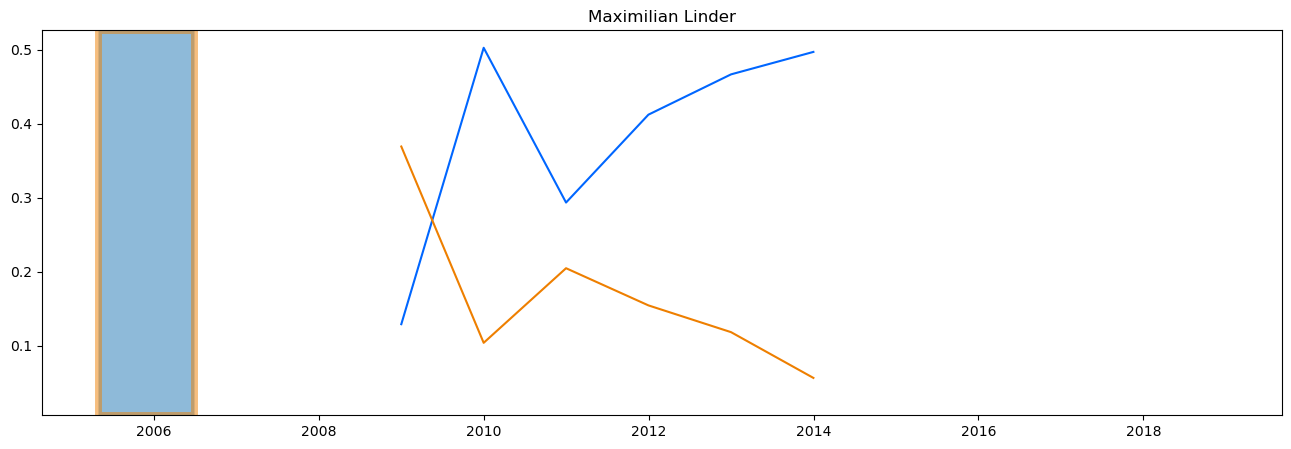

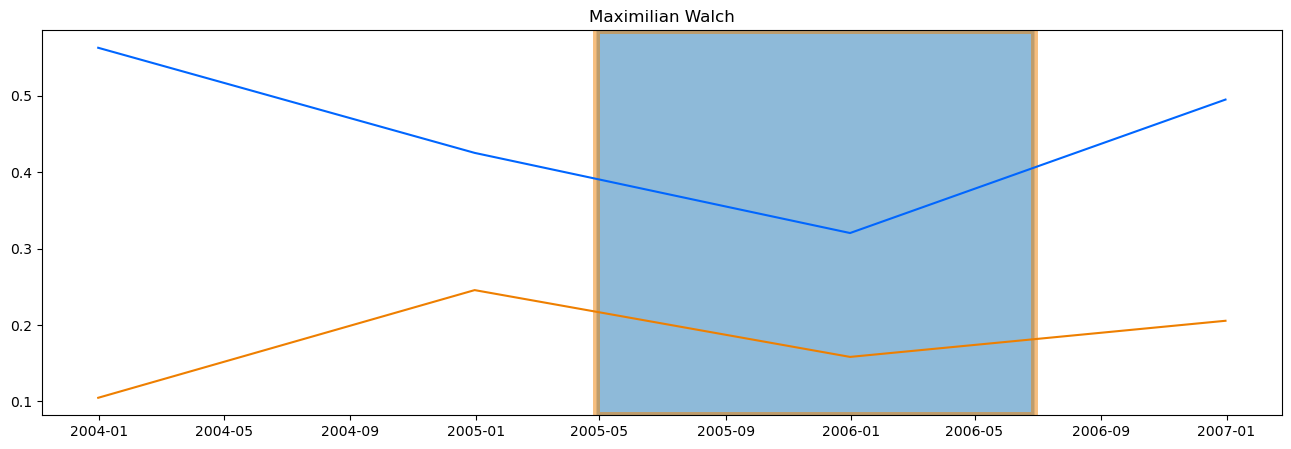

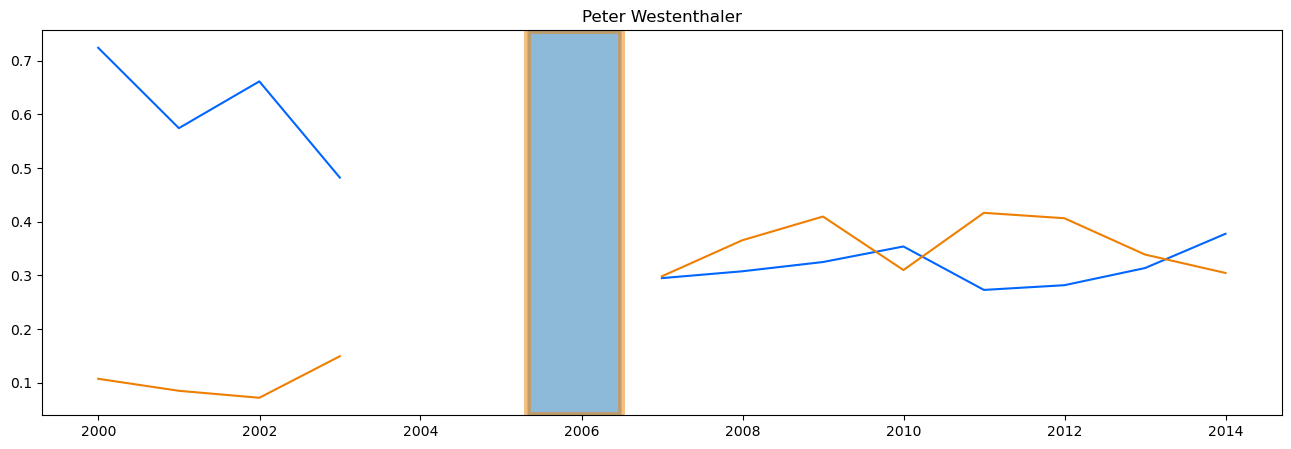

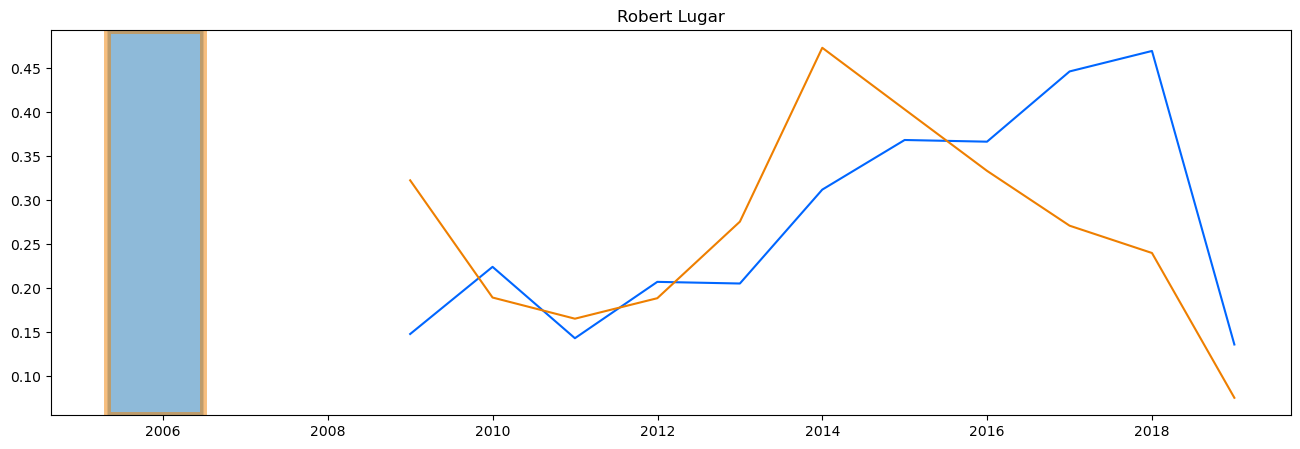

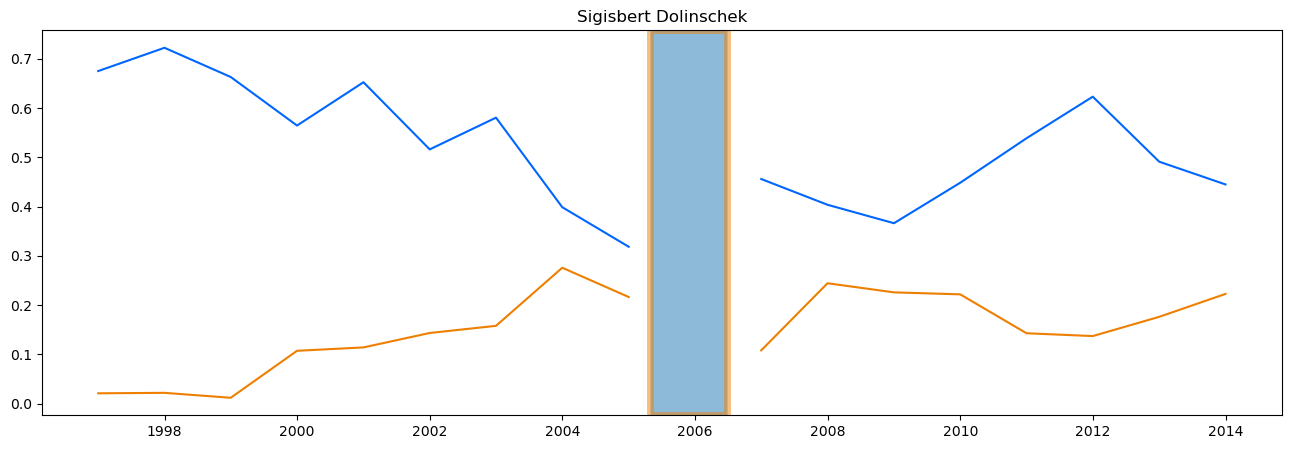

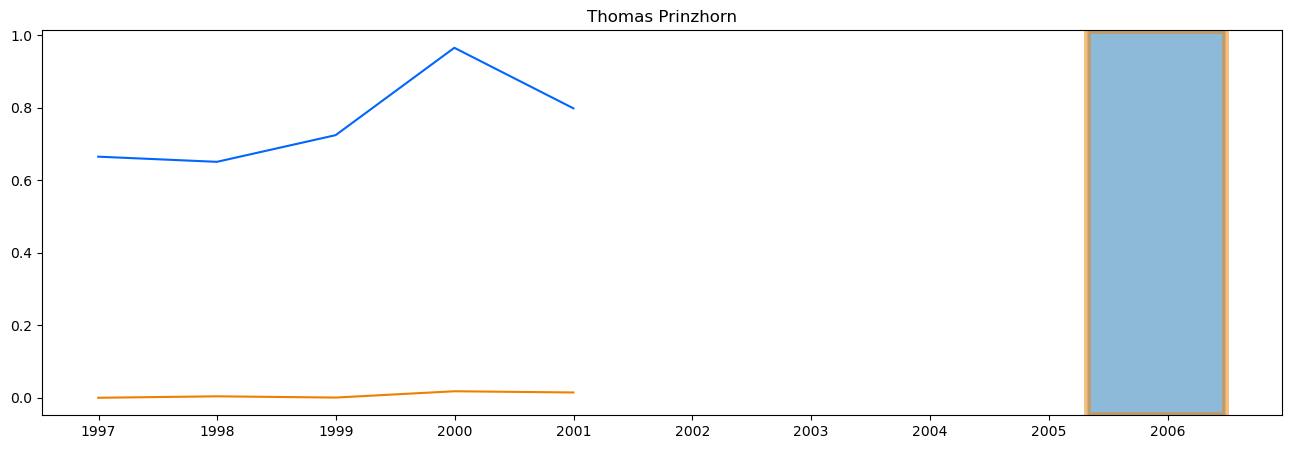

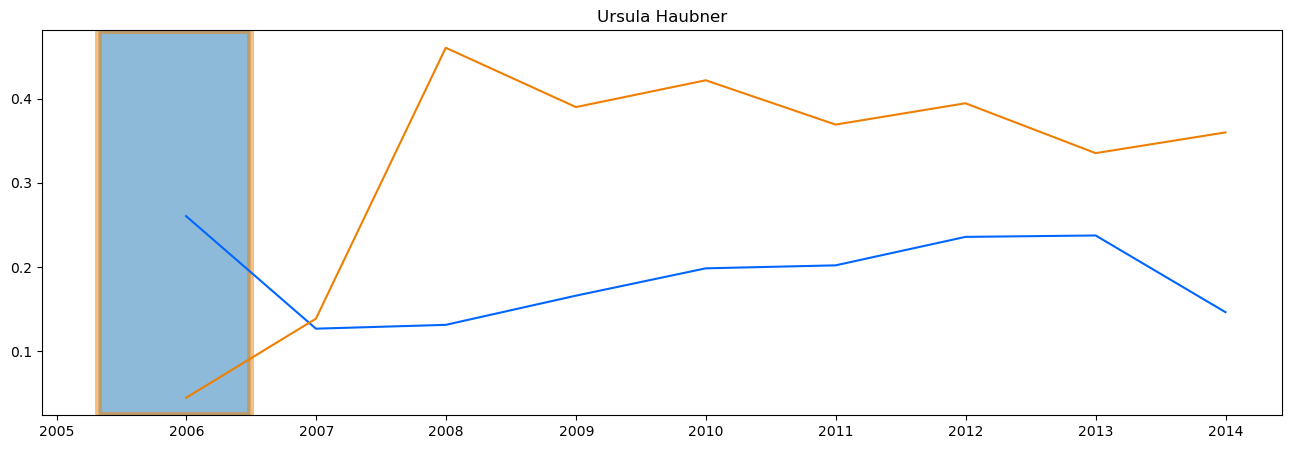

In [39]:
'''MPs that left the FPÖ for the BZÖ'''

mp= ['Anton Wattaul','Christoph Hagen','Elmar Lichtenegger','Erich Tadler','Ernest Windholz','Ewald Stadler','Gernot Darmann','Herbert Scheibner','Josef Bucher','Josef Jury','Klaus Wittauer','Magda Bleckmann','Mares Rossmann','Marialuise Mittermüller','Markus Fauland','Martin Strutz','Maximilian Linder','Maximilian Walch','Peter Westenthaler','Robert Lugar','Sigisbert Dolinschek','Thomas Prinzhorn','Ursula Haubner']

for m in mp: 
    create_graph_mp(m, df, 2, 5)

(204, 18)


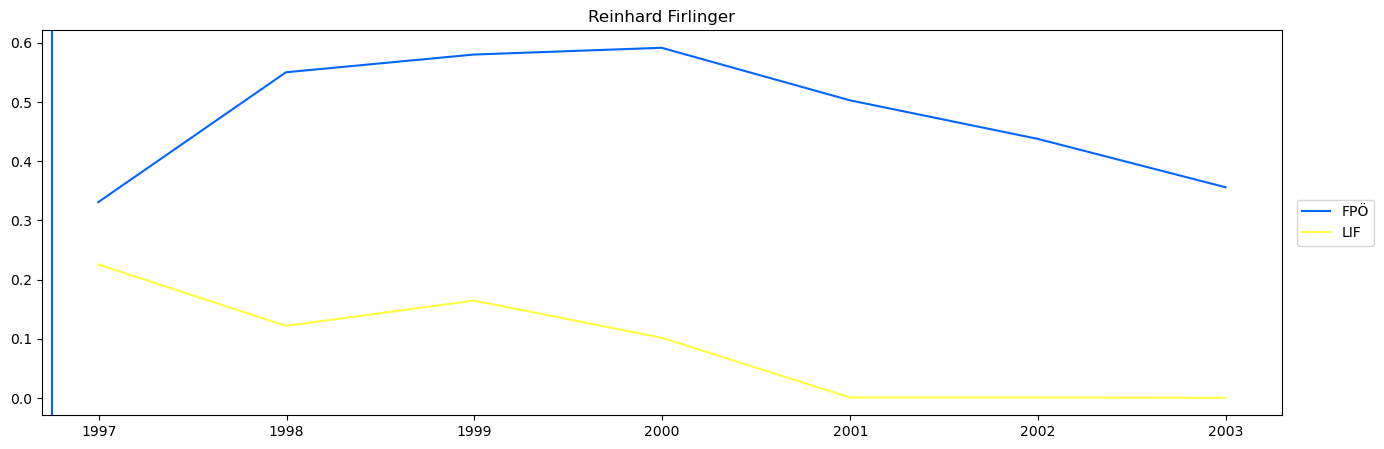

In [57]:
'''MPs that left the LIF for FPÖ'''
create_graph_mp("Reinhard Firlinger", df,2, 4, 1996,10,3)

(55, 18)
(408, 18)
(279, 18)
(145, 18)
(431, 18)
(66, 18)


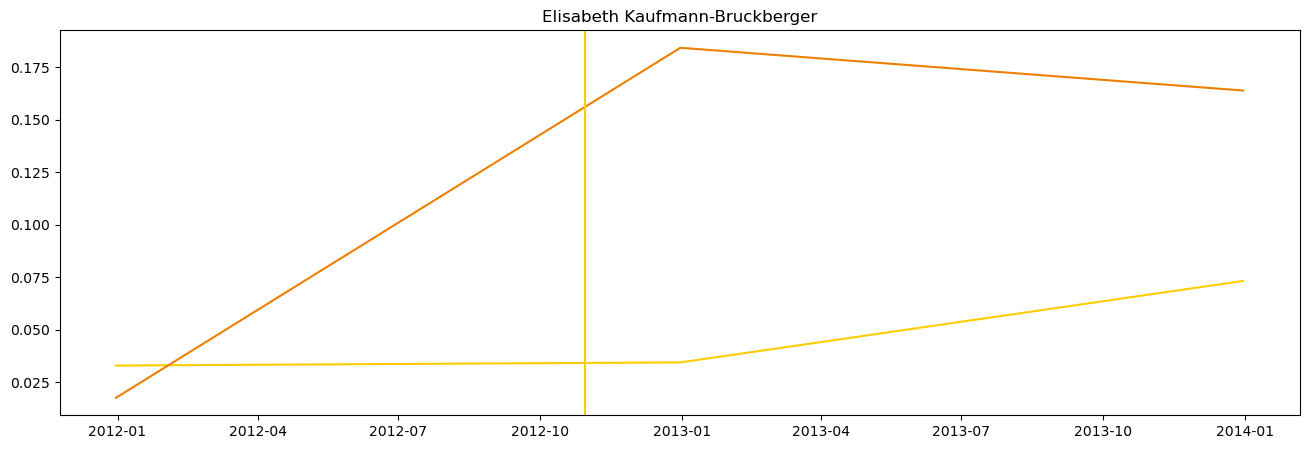

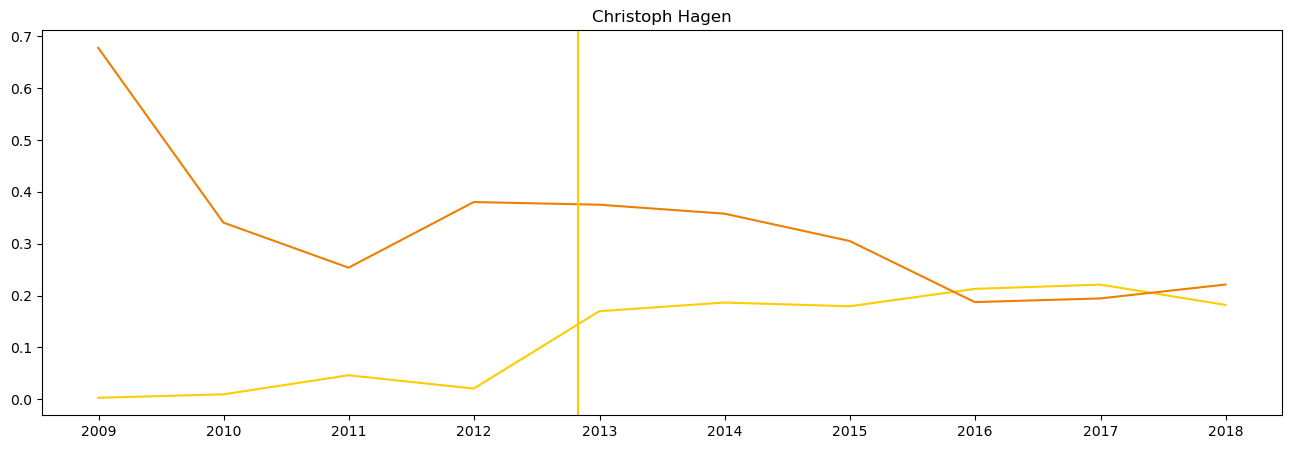

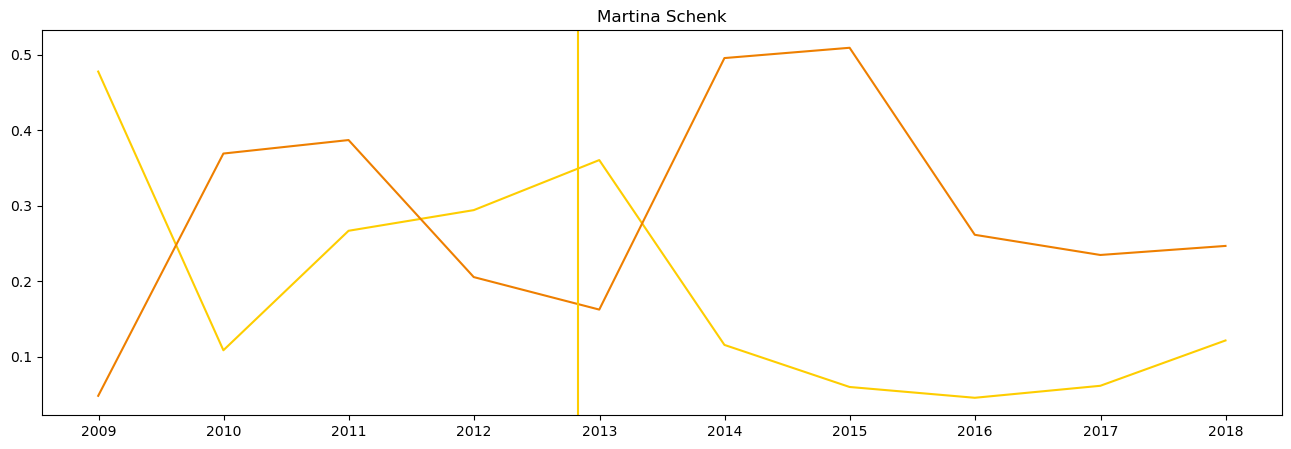

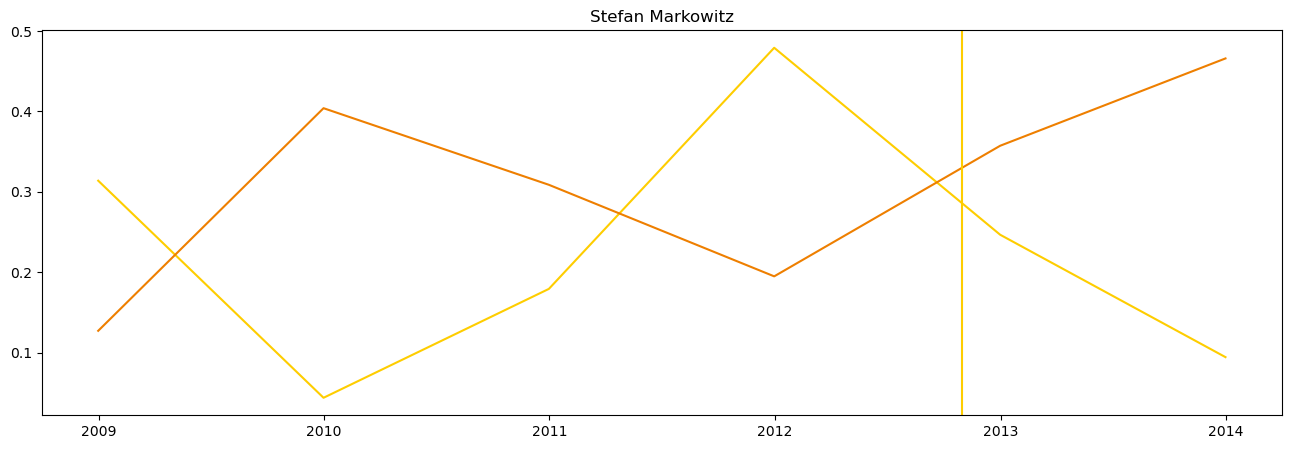

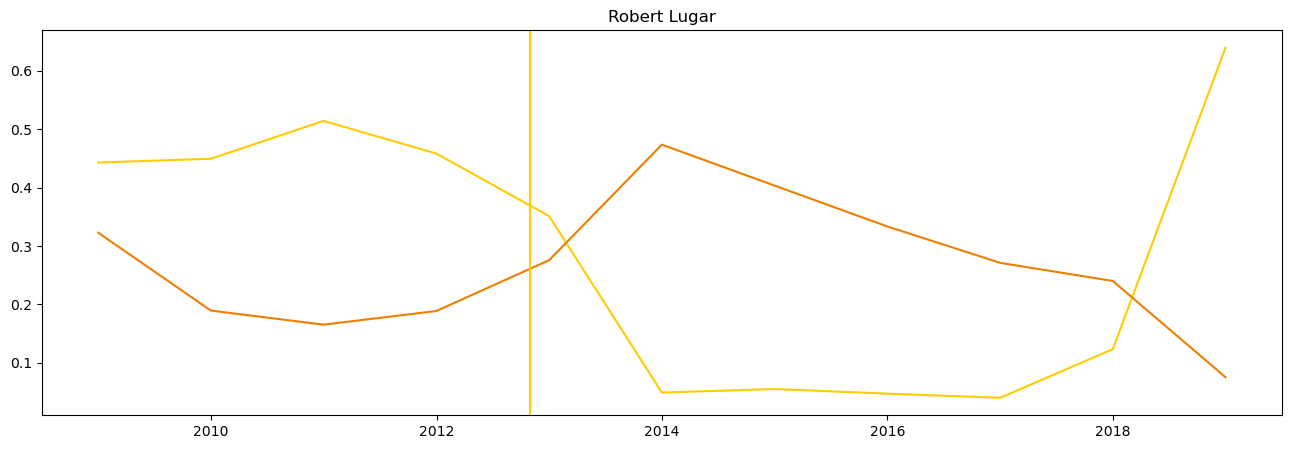

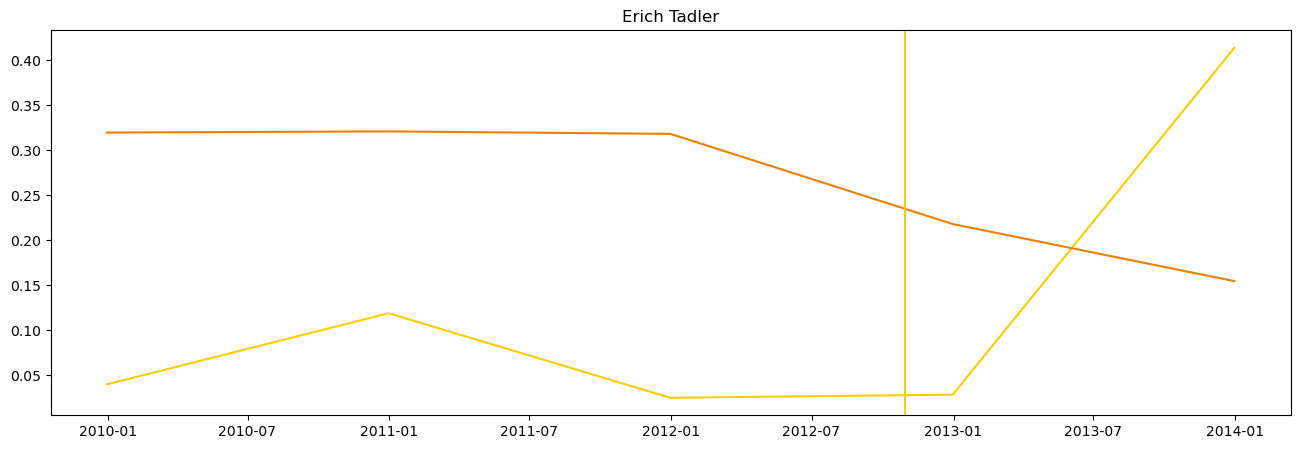

In [46]:
'''MPS that left BZÖ for STORNACH'''
bz_mp= ['Elisabeth Kaufmann-Bruckberger','Christoph Hagen','Martina Schenk','Stefan Markowitz', 'Robert Lugar', 'Erich Tadler']
for b in bz_mp:
    create_graph_mp(b, df, 7,5, 2012, 10, 30)

(55, 18)


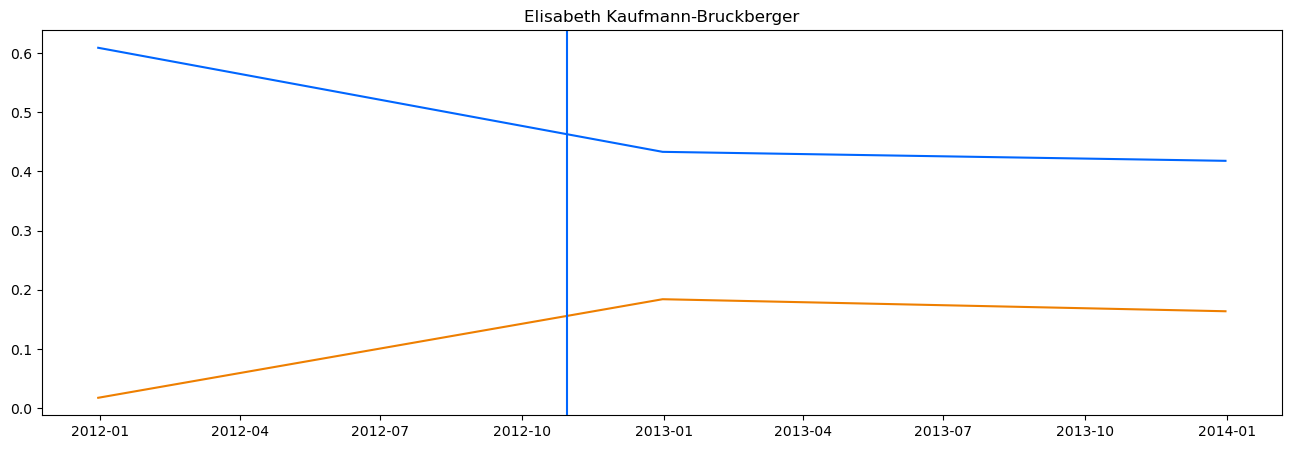

In [48]:
create_graph_mp("Elisabeth Kaufmann-Bruckberger", df, 2, 5, 2012, 10, 30)

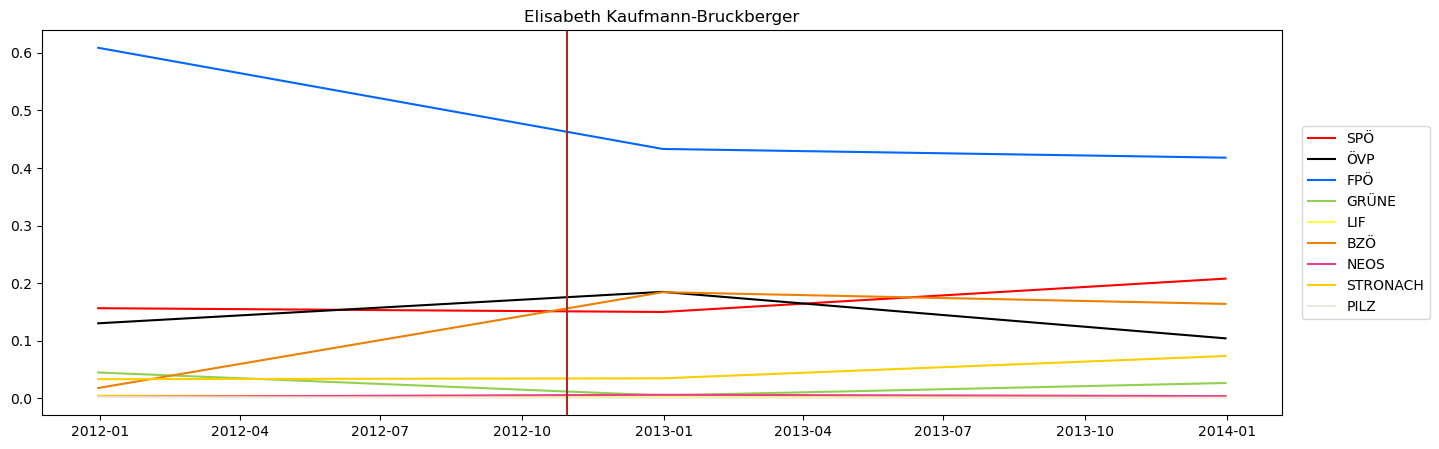

In [8]:
mp="Elisabeth Kaufmann-Bruckberger"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()

ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))


plt.title(mp)
plt.axvline(datetime(2012,10,30), color='brown')

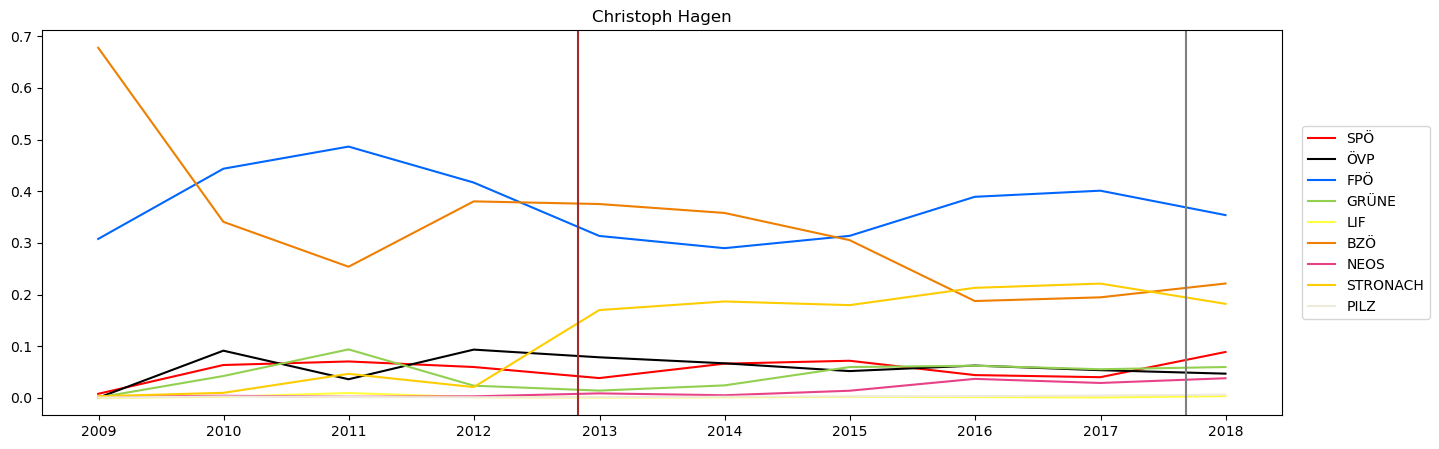

In [9]:
mp="Christoph Hagen"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)
plt.axvline(datetime(2012,10,30), color='brown')
plt.axvline(datetime(2017,9,8), color='grey')

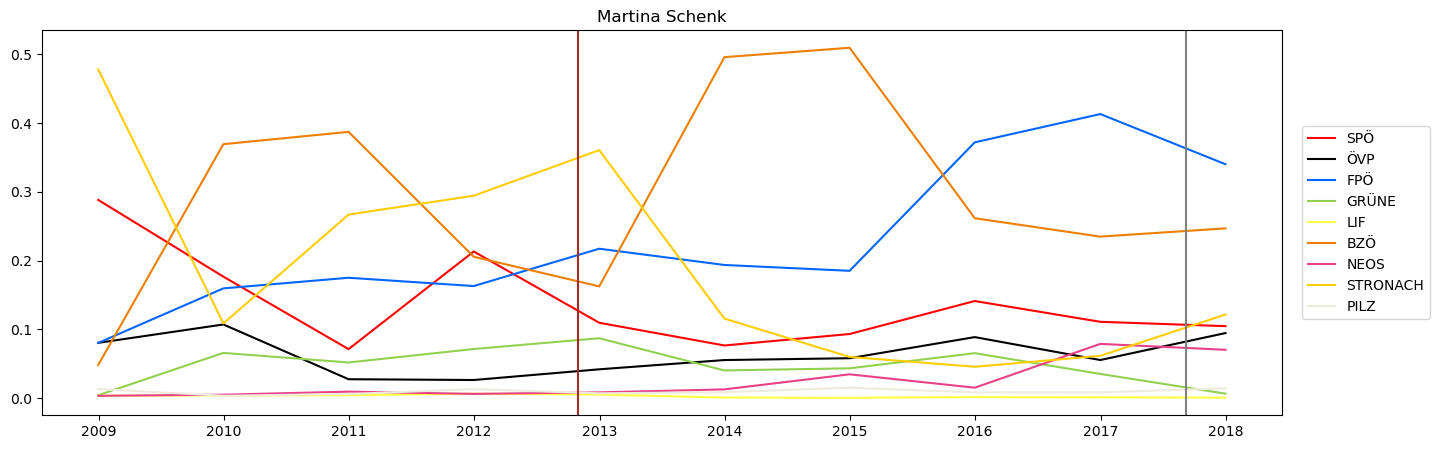

In [10]:
mp="Martina Schenk"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)
plt.axvline(datetime(2012,10,30), color='brown')
plt.axvline(datetime(2017,9,8), color='grey')

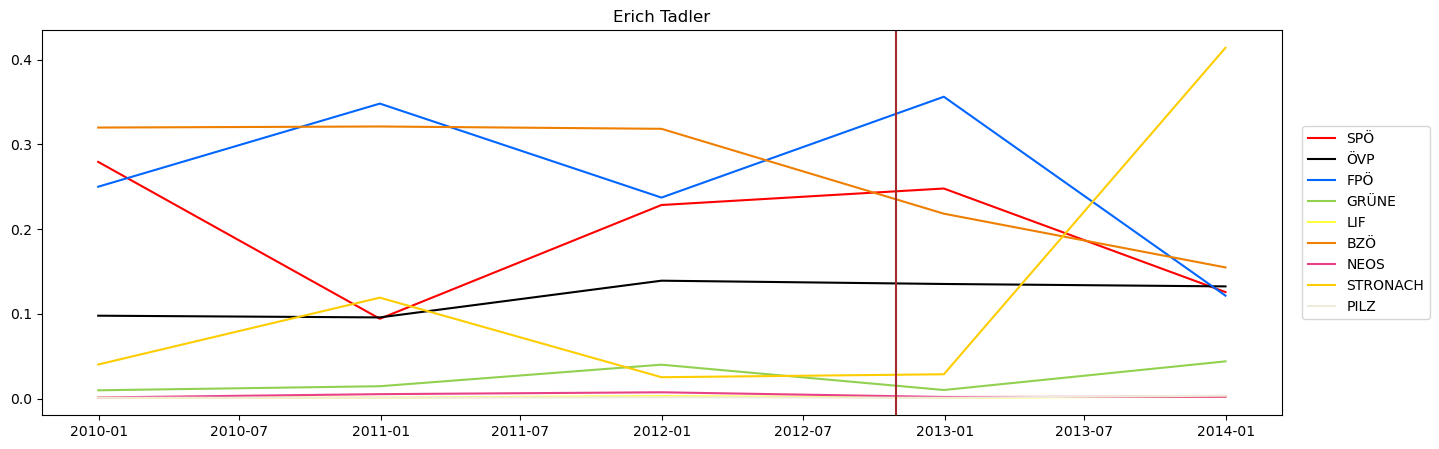

In [11]:
mp="Erich Tadler"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)
plt.axvline(datetime(2012,10,30), color='brown')
#plt.axvline(datetime(2017,9,8), color='grey')

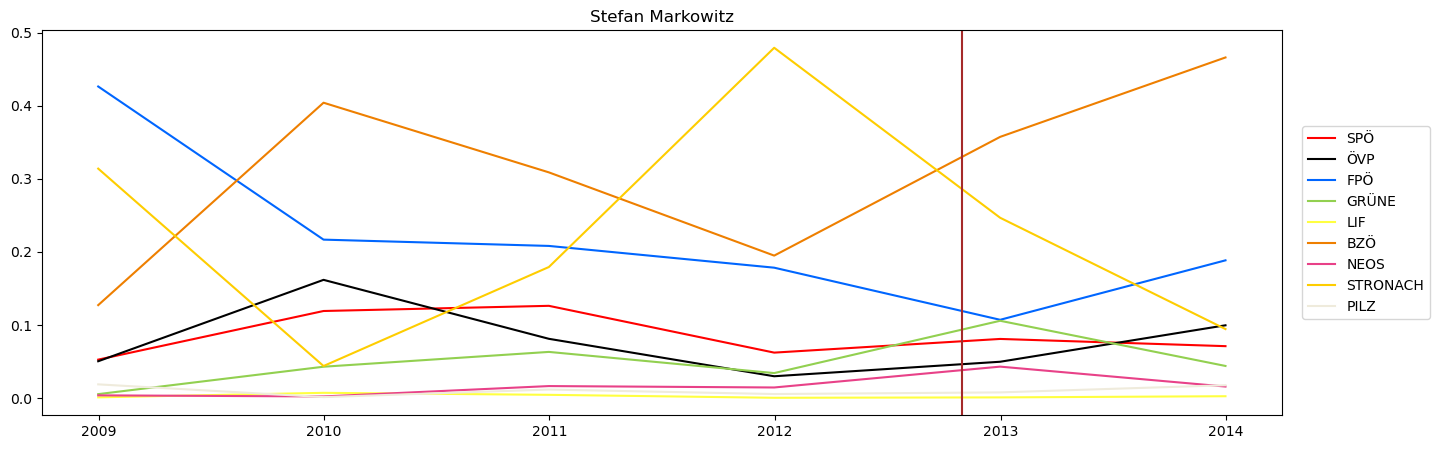

In [12]:
mp="Stefan Markowitz"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)
plt.axvline(datetime(2012,10,30), color='brown')
#plt.axvline(datetime(2017,9,8), color='grey')

(52, 18)


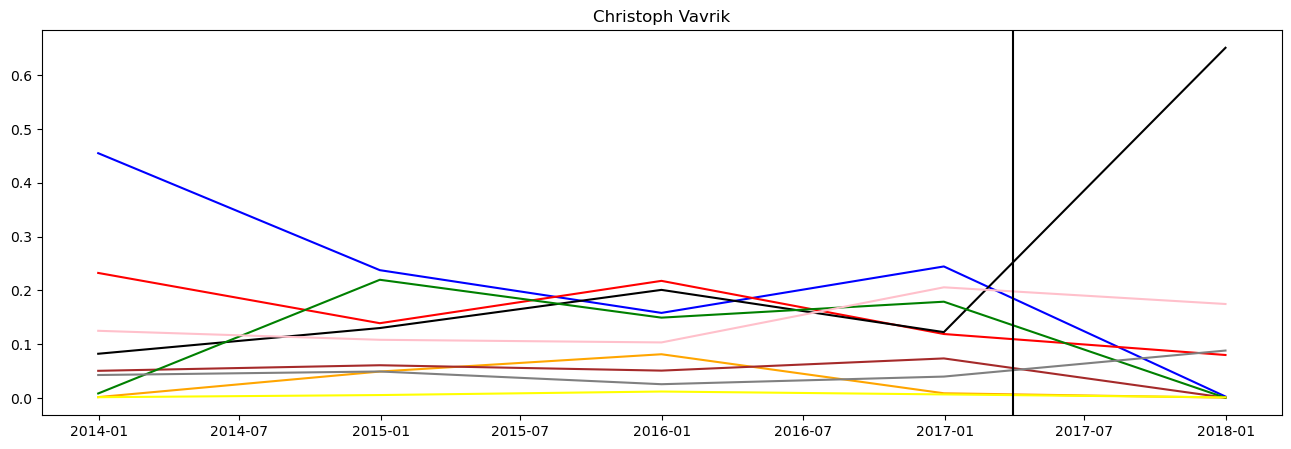

In [54]:
mp="Christoph Vavrik"

mp_df=df[df['speaker']==mp]
print(mp_df.shape)
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))
    
plt.title(mp)
plt.axvline(datetime(2017,3,31), color='black')
#plt.axvline(datetime(2017,8,11), color='blue')
#plt.axvline(datetime(2011,6,19), color='grey')

Text(0.5, 1.0, 'Angelika Mlinar')

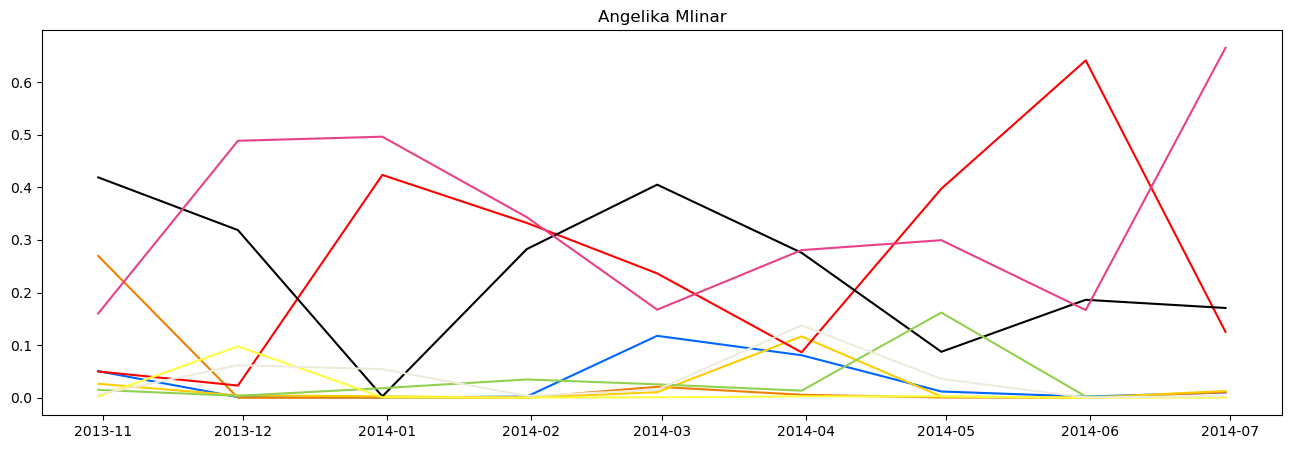

In [75]:
mp="Rosa Mlinar"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('m').mean()
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))
    
plt.title('Angelika Mlinar')

Text(0.5, 1.0, 'Robert Lugar')

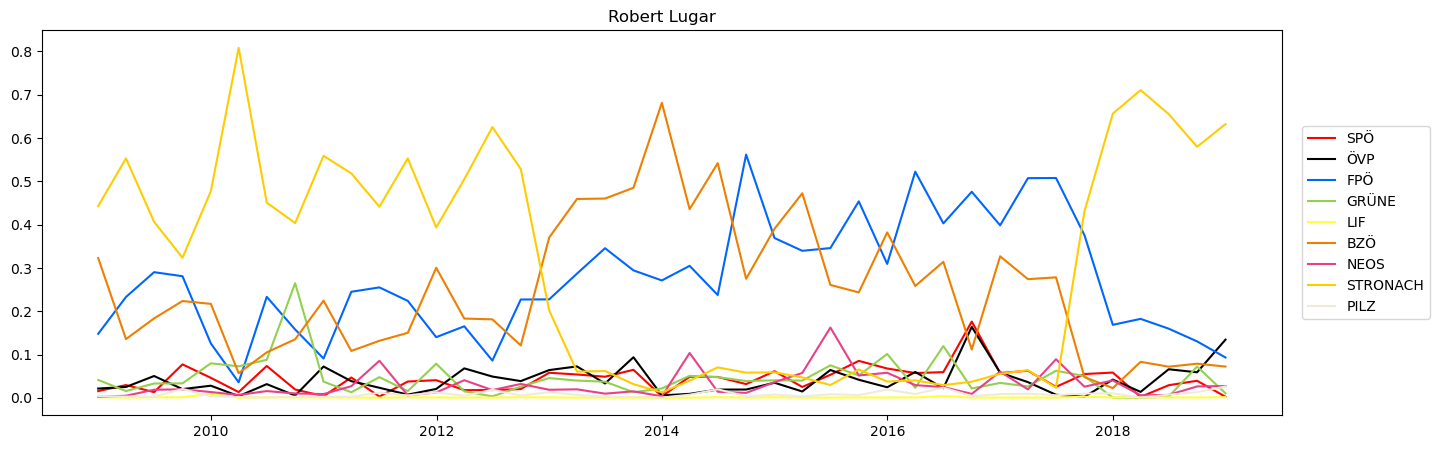

In [13]:
mp="Robert Lugar"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('q').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title('Robert Lugar')

Text(0.5, 1.0, 'Beate Meinl-Reisinger')

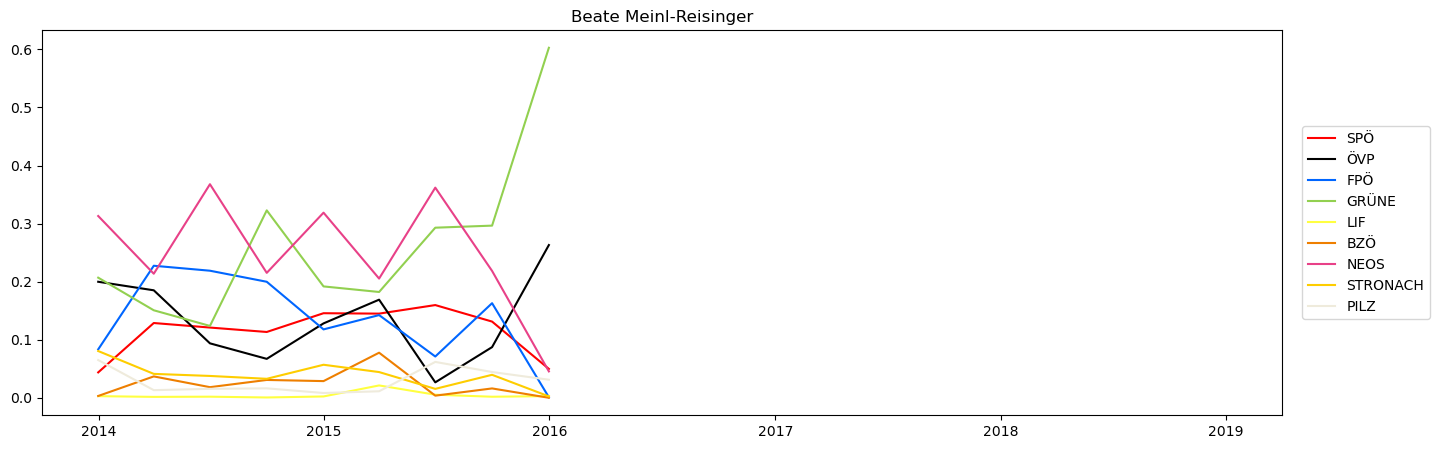

In [13]:
mp="Beate Meinl-Reisinger"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))

dayly = mp_df.resample('q').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)

Text(0.5, 1.0, 'Matthias Strolz')

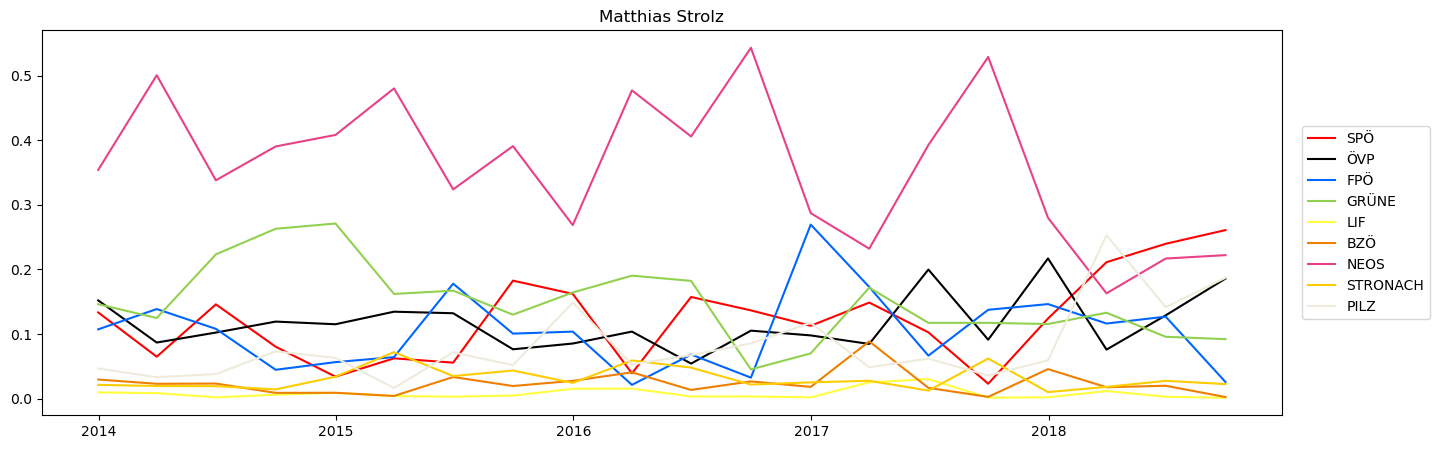

In [14]:
mp="Matthias Strolz"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))

dayly = mp_df.resample('q').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)

Text(0.5, 1.0, 'Andrea Gessl-Ranftl')

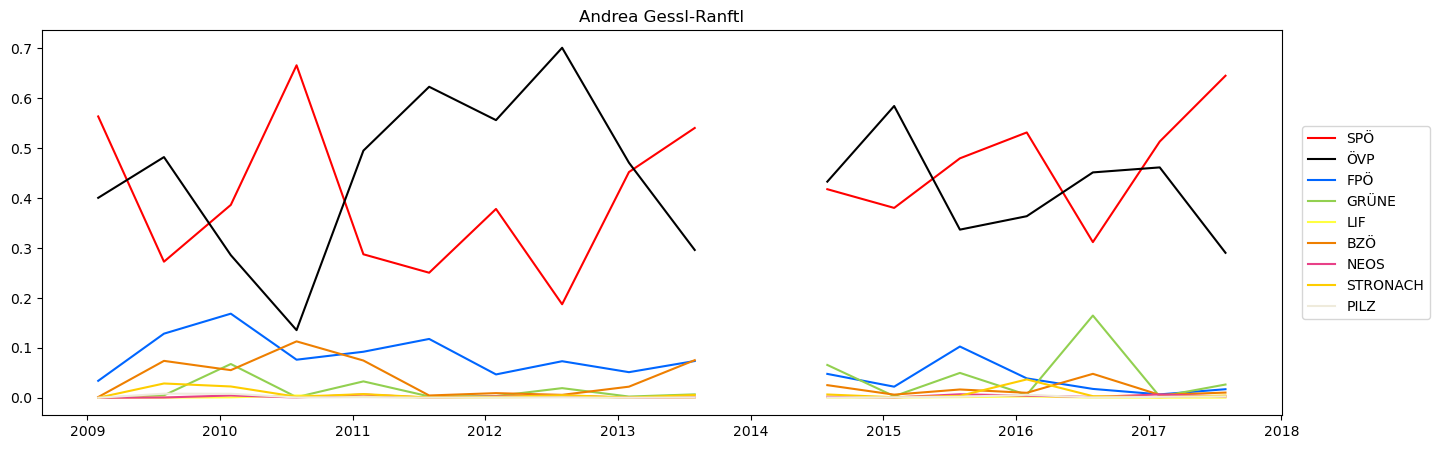

In [20]:
mp="Andrea Gessl-Ranftl"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))

dayly = mp_df.resample('6m').mean()
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

labels = ['SPÖ','ÖVP','FPÖ','GRÜNE','LIF','BZÖ','NEOS','STRONACH','PILZ']
ax.legend(labels, loc='right',bbox_to_anchor=(1.125, 0.5))
    
plt.title(mp)

Text(0.5, 1.0, 'Gerhard Köfer')

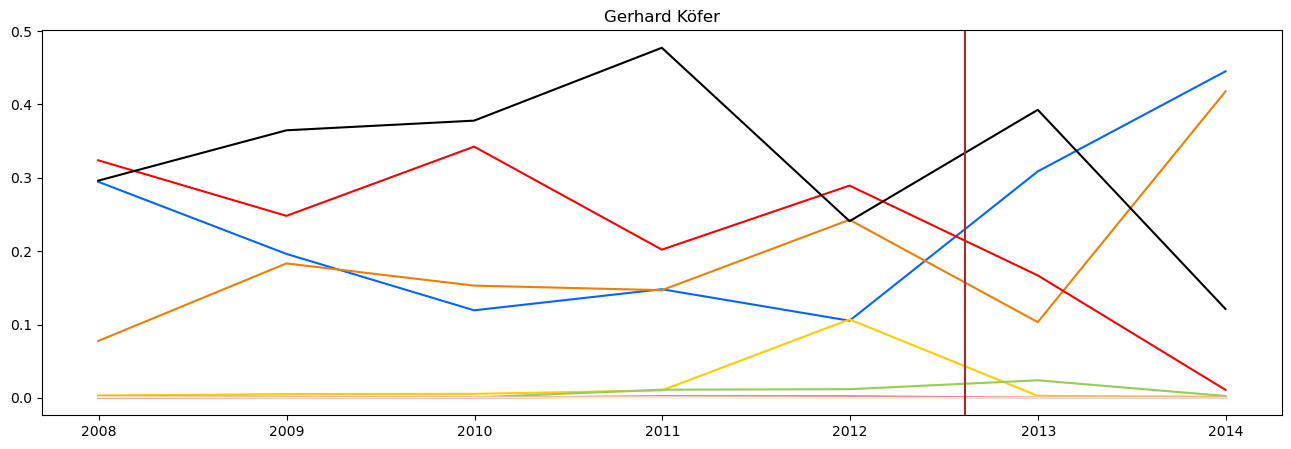

In [85]:
mp="Gerhard Köfer"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))
plt.axvline(datetime(2012,8,12), color='brown')

    
plt.title(mp)

Text(0.5, 1.0, 'Peter Pilz')

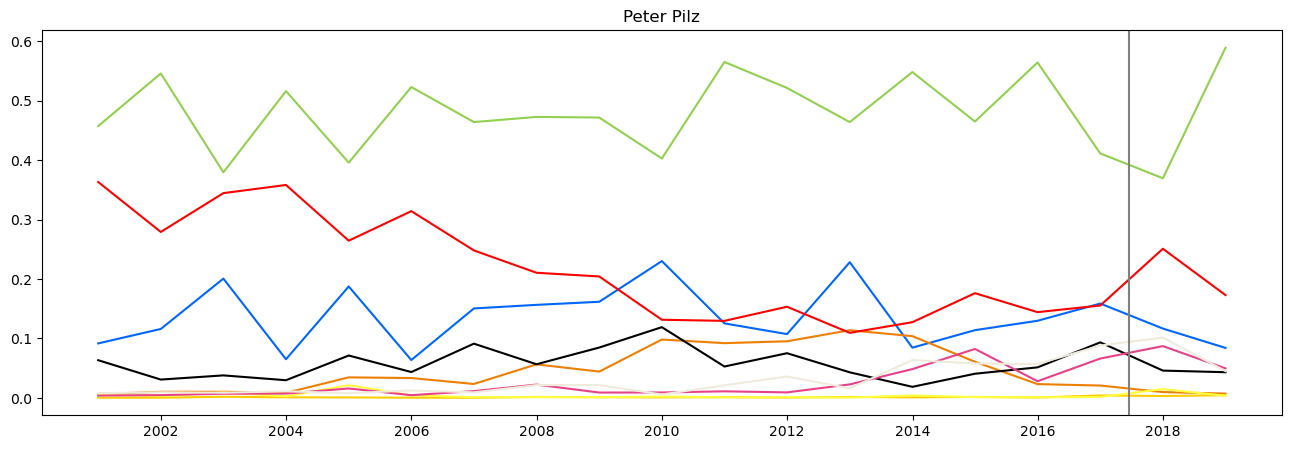

In [84]:
mp="Peter Pilz"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[2], color=party_colour_dict.get(2,'grey'))
ax.plot(dayly.index, dayly[5], color=party_colour_dict.get(5,'grey'))
ax.plot(dayly.index, dayly[7], color=party_colour_dict.get(7,'grey'))
ax.plot(dayly.index, dayly[0], color=party_colour_dict.get(0,'grey'))
ax.plot(dayly.index, dayly[1], color=party_colour_dict.get(1,'grey'))
ax.plot(dayly.index, dayly[3], color=party_colour_dict.get(3,'grey'))
ax.plot(dayly.index, dayly[4], color=party_colour_dict.get(4,'grey'))
ax.plot(dayly.index, dayly[6], color=party_colour_dict.get(6,'grey'))
ax.plot(dayly.index, dayly[8], color=party_colour_dict.get(8,'grey'))

plt.axvline(datetime(2017,6,17), color='grey')
    
plt.title(mp)

Text(0.5, 1.0, 'Daniela Holzinger-Vogtenhuber')

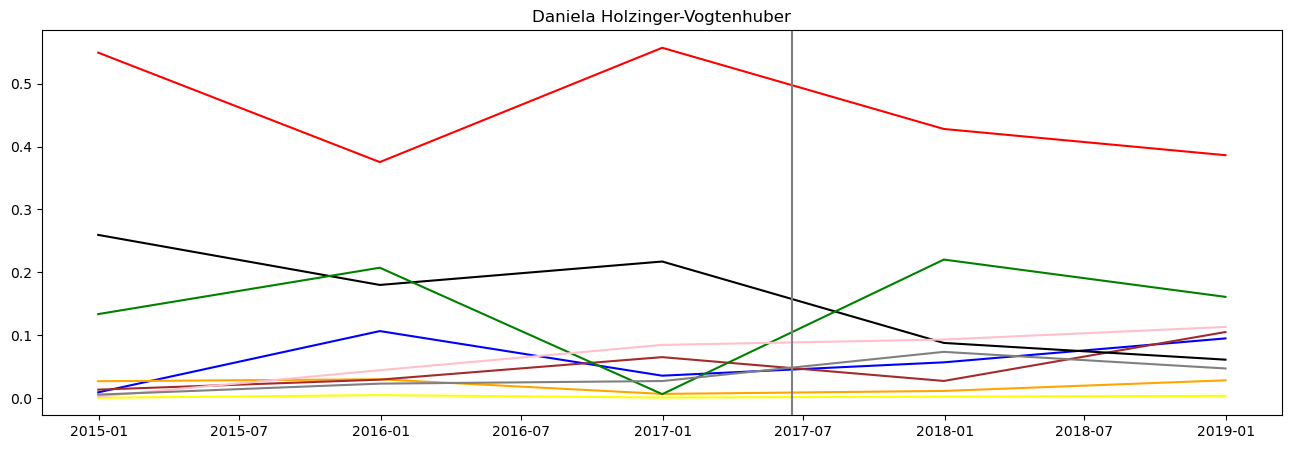

In [61]:
mp="Daniela Holzinger-Vogtenhuber"

mp_df=df[df['speaker']==mp]
fig, ax = plt.subplots(figsize=(16, 5))
    
dayly = mp_df.resample('y').mean()
ax.plot(dayly.index, dayly[2], color='blue')
ax.plot(dayly.index, dayly[5], color='orange')
ax.plot(dayly.index, dayly[7], color='brown')
ax.plot(dayly.index, dayly[0], color='red')
ax.plot(dayly.index, dayly[1], color='black')
ax.plot(dayly.index, dayly[3], color='green')
ax.plot(dayly.index, dayly[4], color='yellow')
ax.plot(dayly.index, dayly[6], color='pink')
ax.plot(dayly.index, dayly[8], color='grey')

plt.axvline(datetime(2017,6,17), color='grey')
    
plt.title(mp)

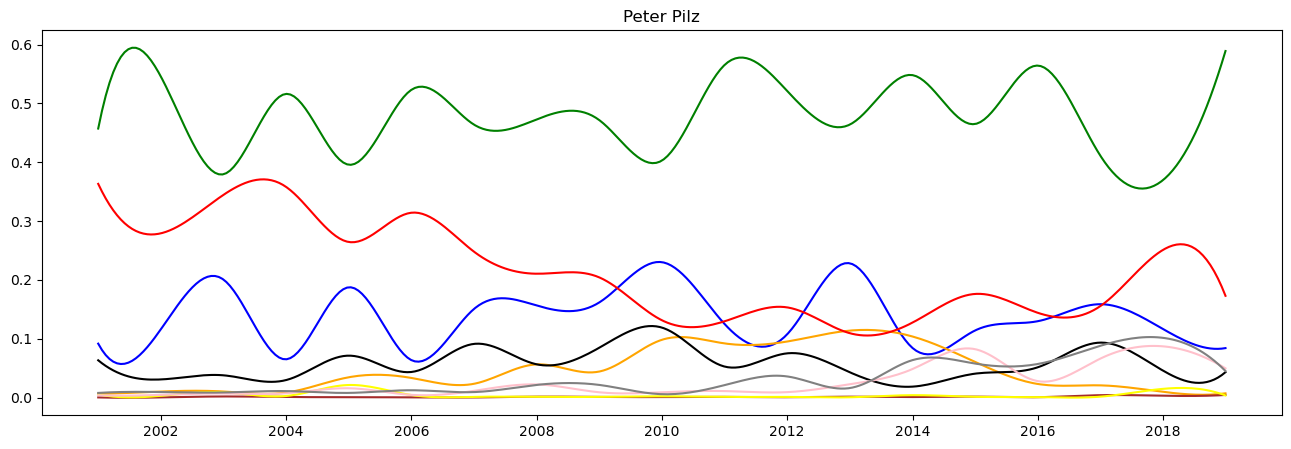

In [85]:
' try rounder curves'

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

mp="Peter Pilz"

mp_df = df[df['speaker'] == mp]
fig, ax = plt.subplots(figsize=(16, 5))

dayly = mp_df.resample('y').mean()

x = np.arange(len(dayly.index))  # numeric x for spline

for col, color in zip([2,5,7,0,1,3,4,6,8],
                      ['blue','orange','brown','red','black','green','yellow','pink','grey']):
    
    y = dayly[col].values
    
    # Create smooth curve
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)  # cubic spline
    y_smooth = spline(x_smooth)

    # Convert back to dates for plotting
    dates_smooth = np.interp(x_smooth, x, dayly.index.astype(np.int64))
    dates_smooth = dates_smooth.astype('datetime64[ns]')
    
    ax.plot(dates_smooth, y_smooth, color=color)

plt.title(mp)
plt.show()


In [62]:
create_graph_mp("Herbert Scheibner", df, 2, 5)

TypeError: create_graph_mp() missing 3 required positional arguments: 'y', 'm', and 'd'

In [63]:
create_graph_mp("Jörg Haider", df,  2, 5)

TypeError: create_graph_mp() missing 3 required positional arguments: 'y', 'm', and 'd'

(444, 18)


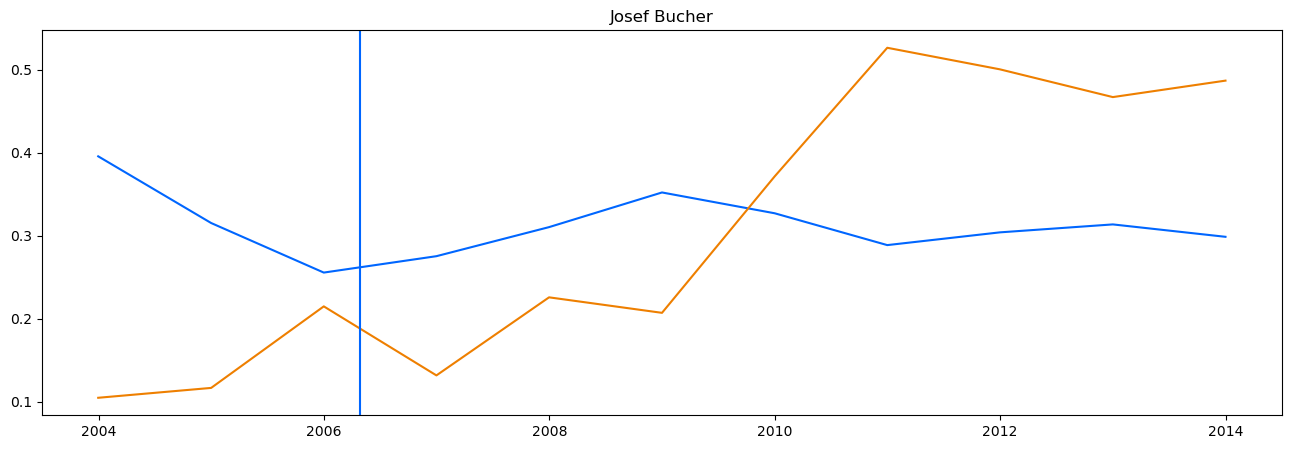

In [64]:
create_graph_mp("Josef Bucher", df,  2, 5, 2006, 4, 28)

(947, 18)
(54, 18)
(211, 18)
(267, 18)
(257, 18)
(170, 18)


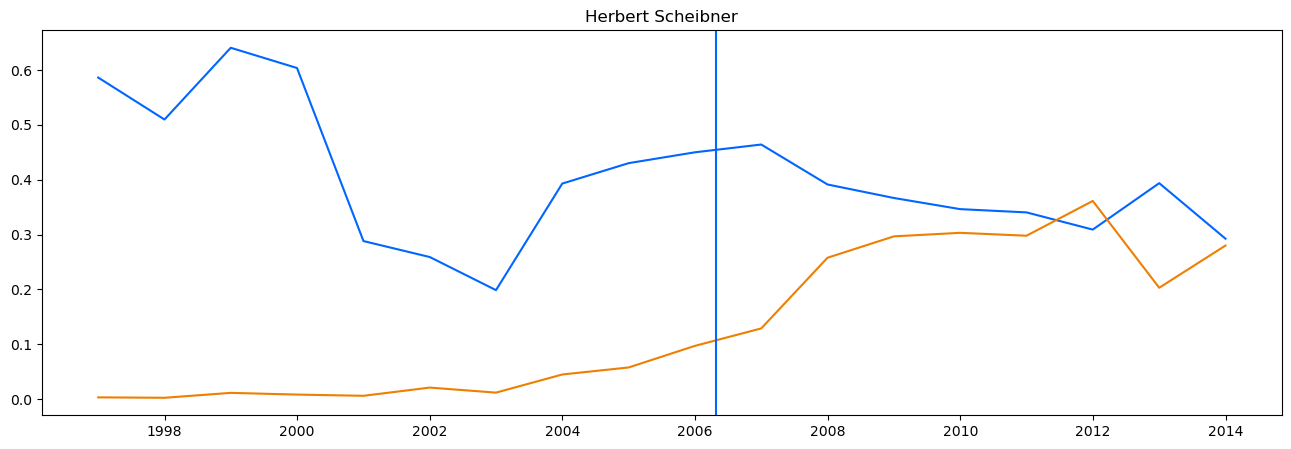

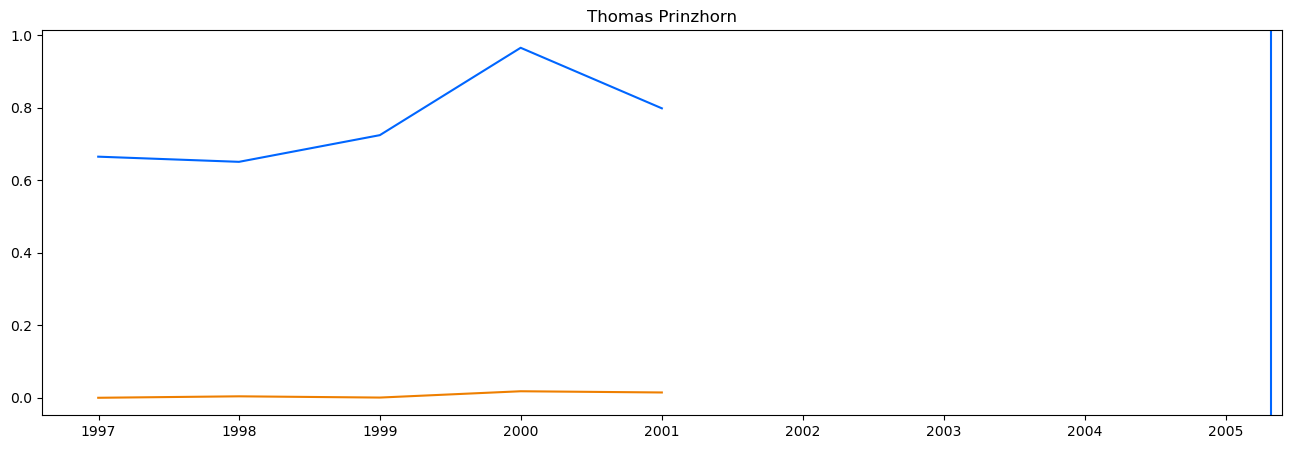

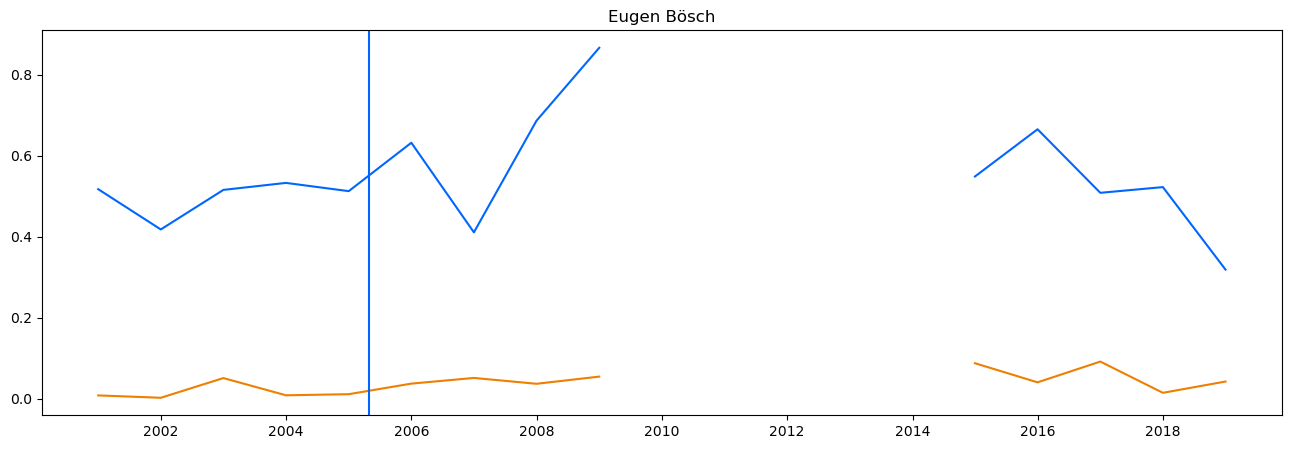

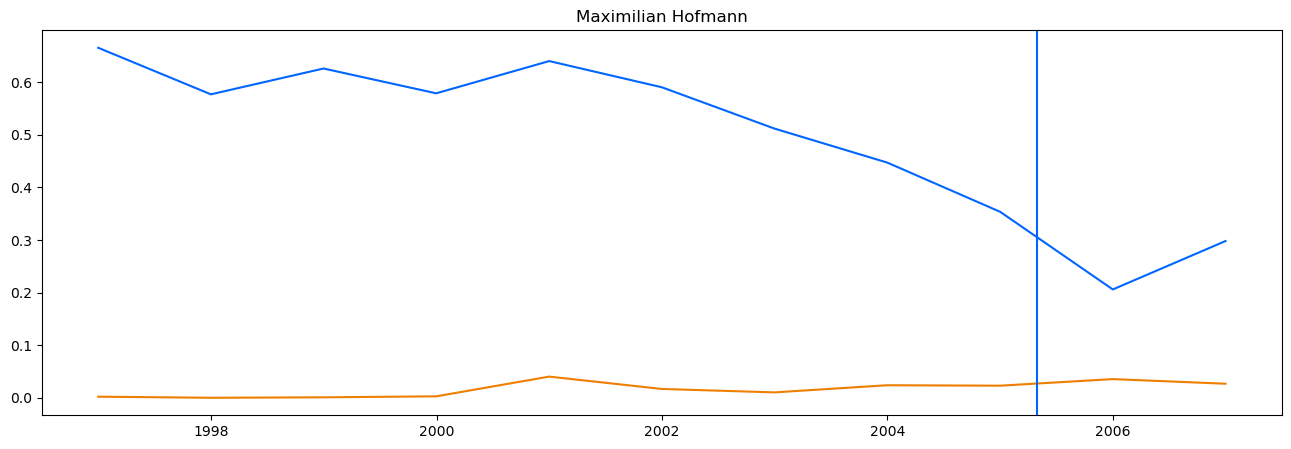

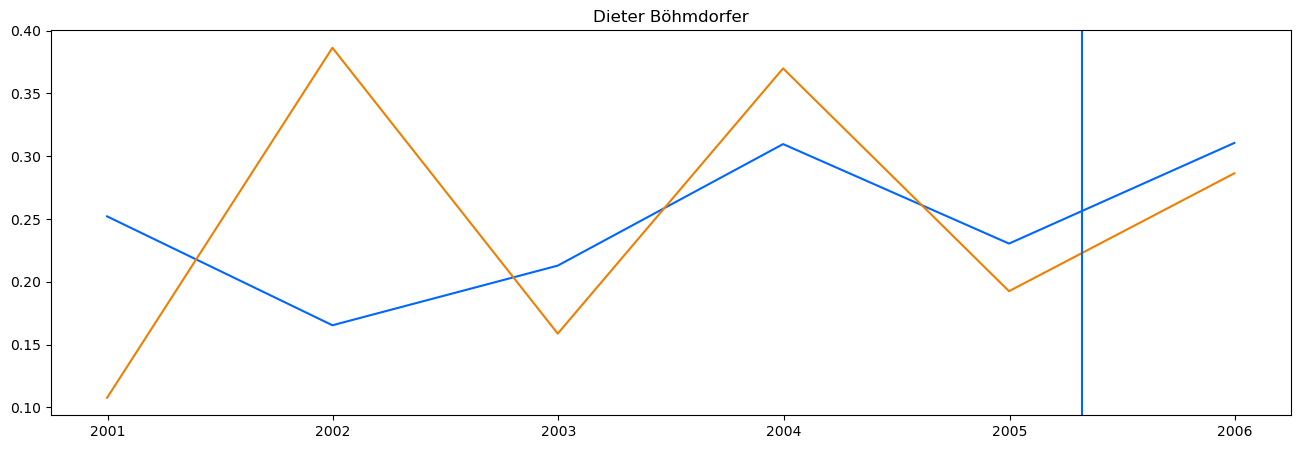

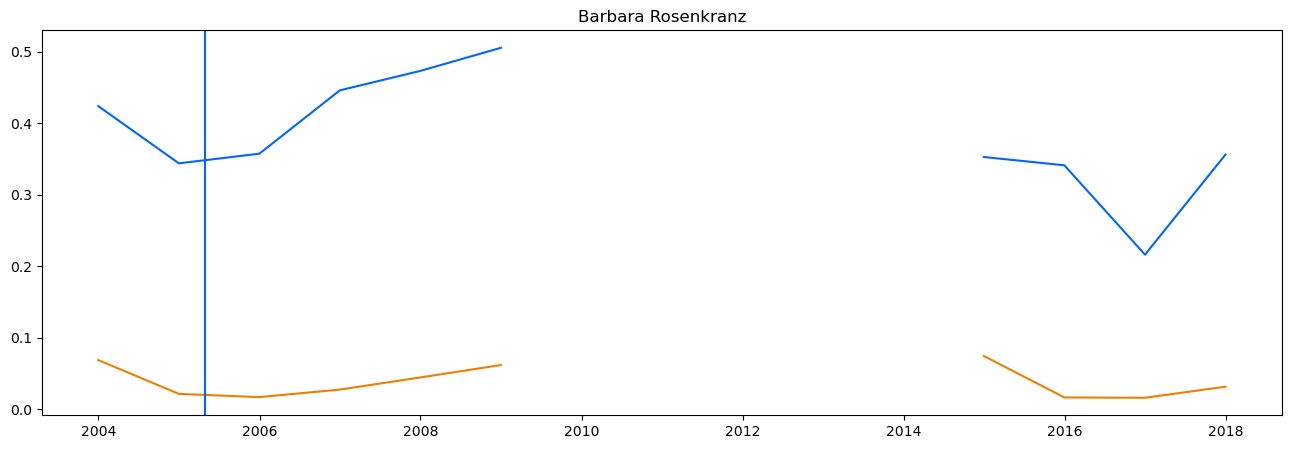

In [65]:
create_graph_mp("Herbert Scheibner", df,  2, 5, 2006, 4, 28)
create_graph_mp("Thomas Prinzhorn", df,  2, 5, 2005, 4, 28)
create_graph_mp("Eugen Bösch", df, 2, 5, 2005, 4, 28)
create_graph_mp("Maximilian Hofmann", df,  2, 5, 2005, 4, 28)
create_graph_mp("Dieter Böhmdorfer", df,  2, 5, 2005, 4, 28)
create_graph_mp("Barbara Rosenkranz", df,  2, 5, 2005, 4, 28)

(267, 18)
(158, 18)
(418, 18)


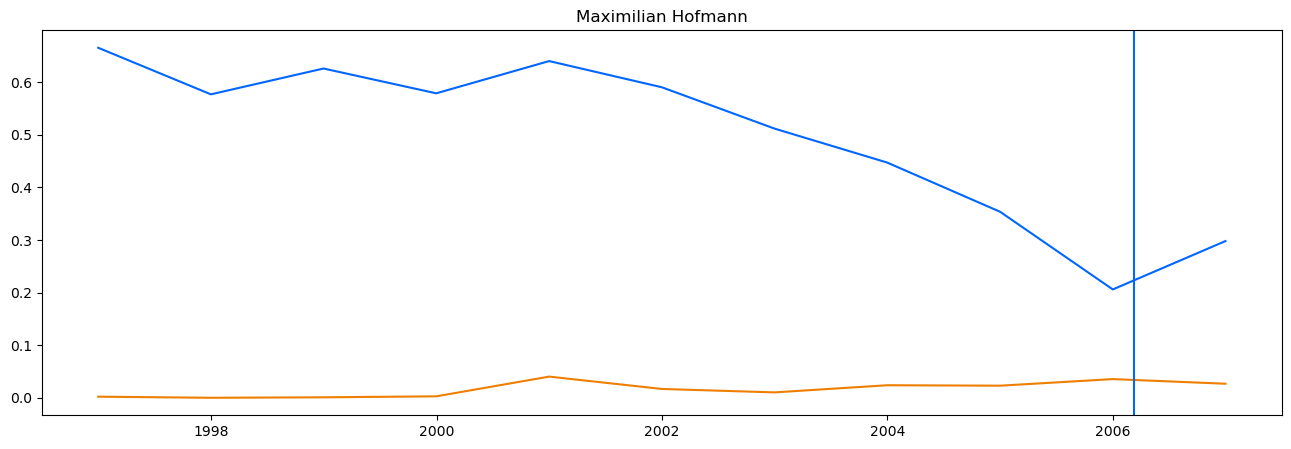

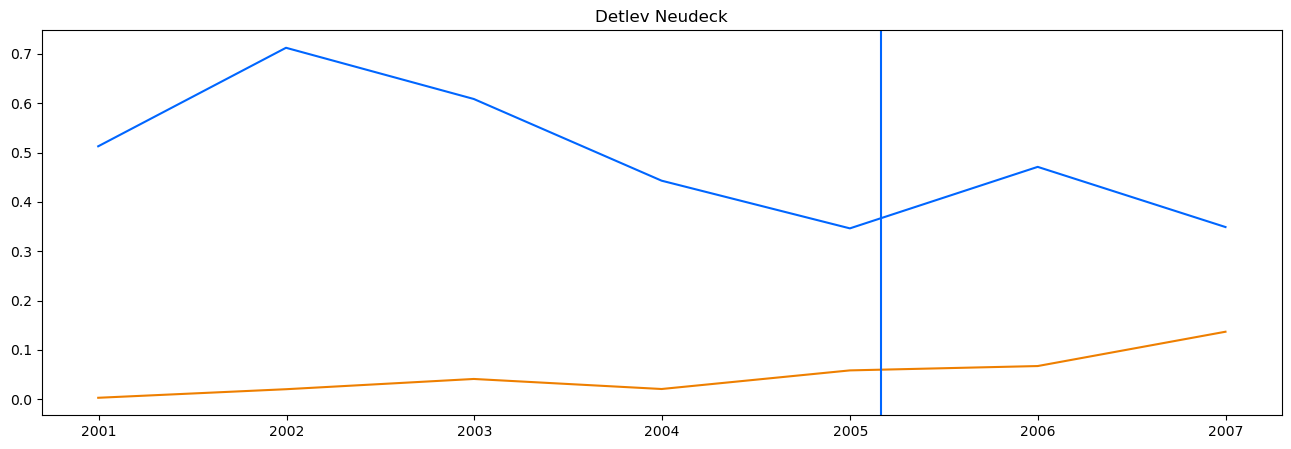

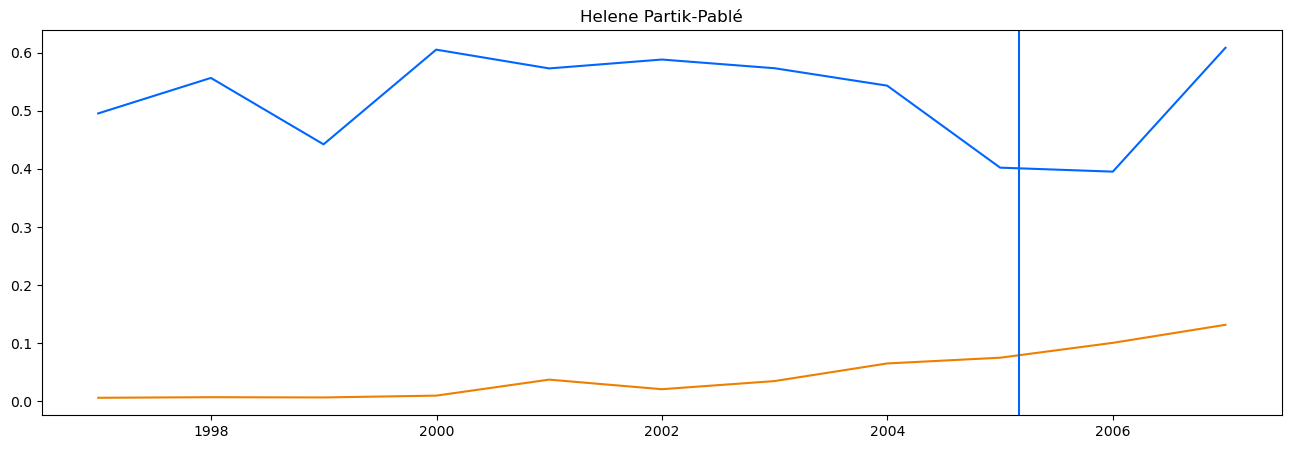

In [66]:
create_graph_mp("Maximilian Hofmann", df,  2, 5, 2006, 3, 9)
create_graph_mp("Detlev Neudeck", df,  2, 5, 2005, 3, 1)
create_graph_mp("Helene Partik-Pablé", df, 2, 5, 2005, 3, 1)

(197, 18)


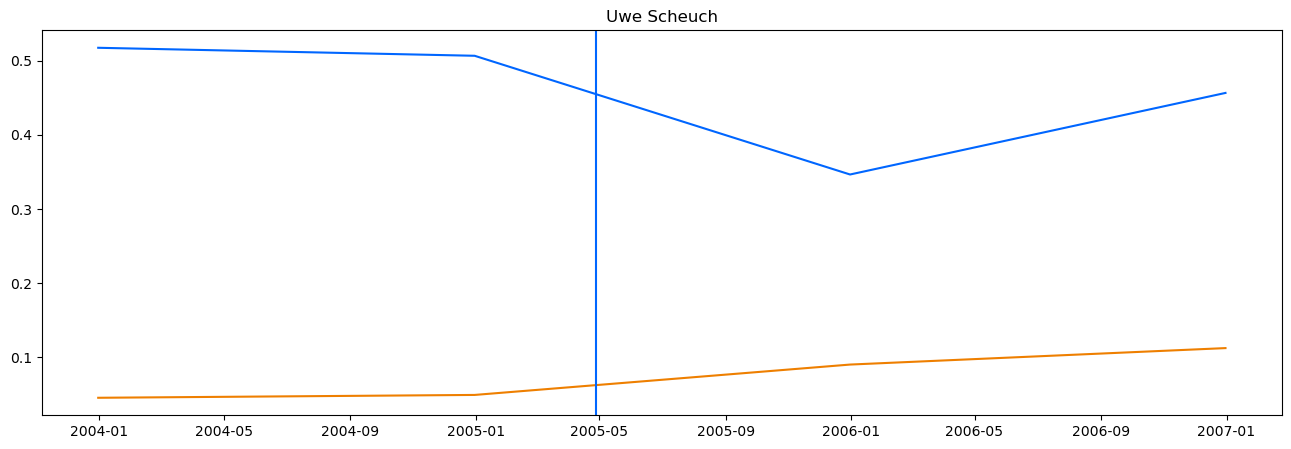

In [68]:
create_graph_mp("Uwe Scheuch", df, 2, 5,2005, 4, 28 )

(192, 18)


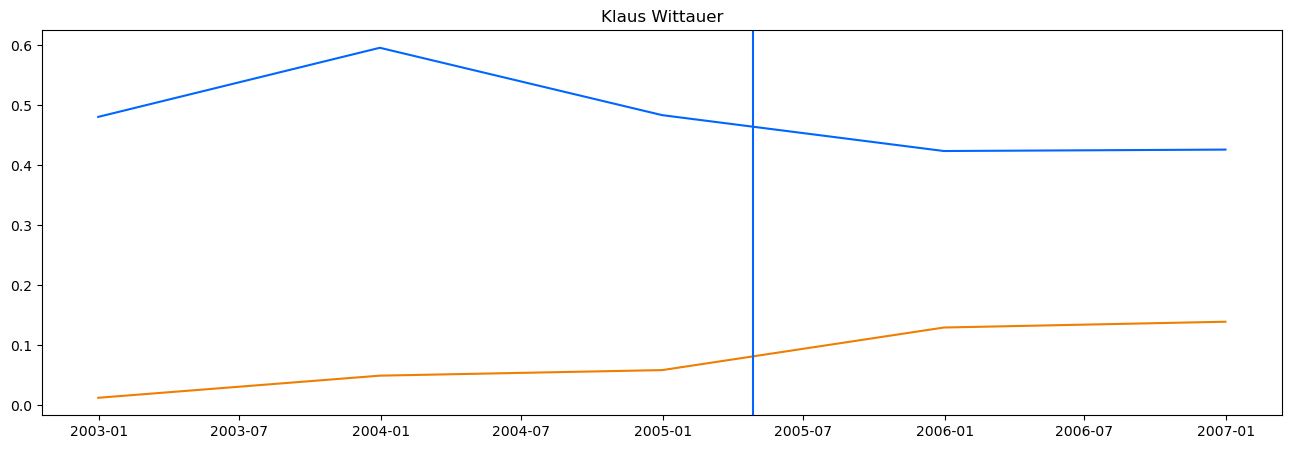

In [69]:
create_graph_mp("Klaus Wittauer", df, 2, 5,2005, 4, 28)

(192, 18)


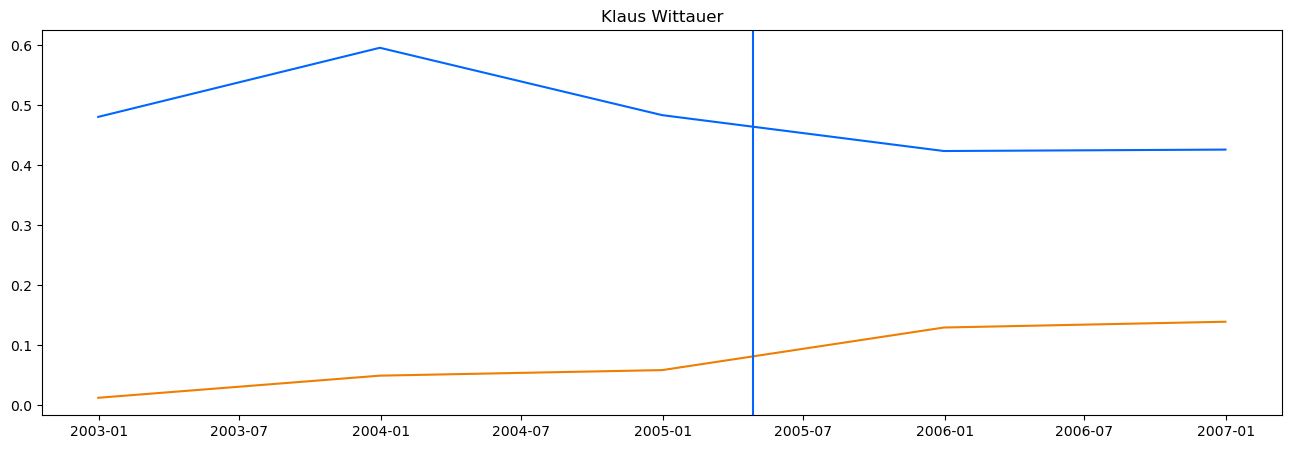

In [70]:
create_graph_mp("Klaus Wittauer", df, 2, 5,2005, 4, 28)

In [72]:
df2=df[df['gov']==2]
df2_F=df2[df2['party']==2]
df2_B=df2[df2['party']==5]

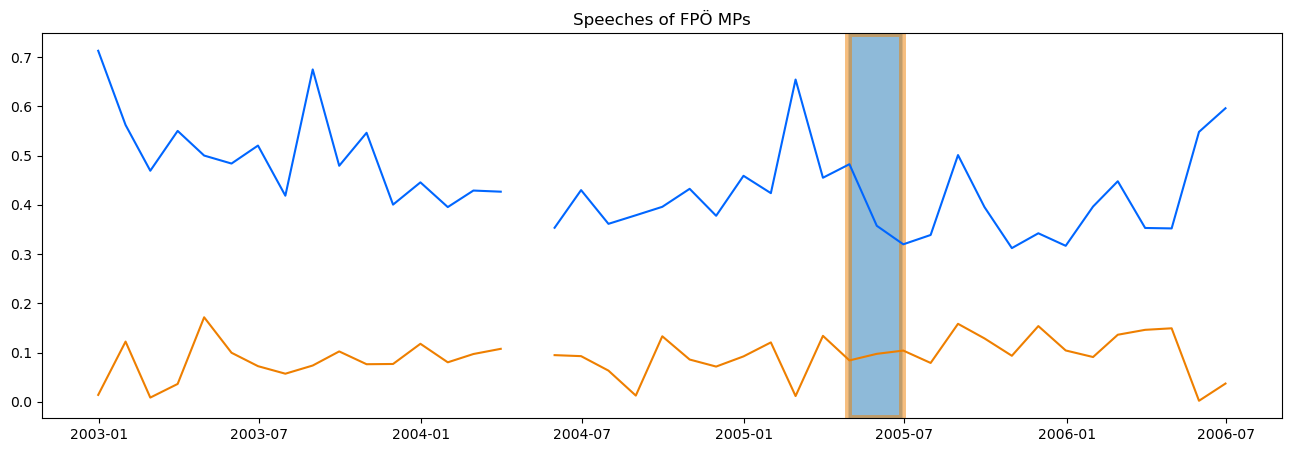

In [73]:
party1=2
party2=5
colour1=party_colour_dict.get(party1,'grey')
colour2=party_colour_dict.get(party2,'grey')
fig, ax = plt.subplots(figsize=(16, 5))
df2_F = df2_F.resample('m').mean()
plt.plot(df2_F.index, df2_F[party1], color= colour1)
plt.plot(df2_F.index, df2_F[party2], color= colour2)
#smoothing the graph
    
plt.title('Speeches of FPÖ MPs')
plt.axvspan(datetime(2005,4,28), datetime(2005, 6, 28), alpha=0.5, edgecolor=colour2, linewidth=5)

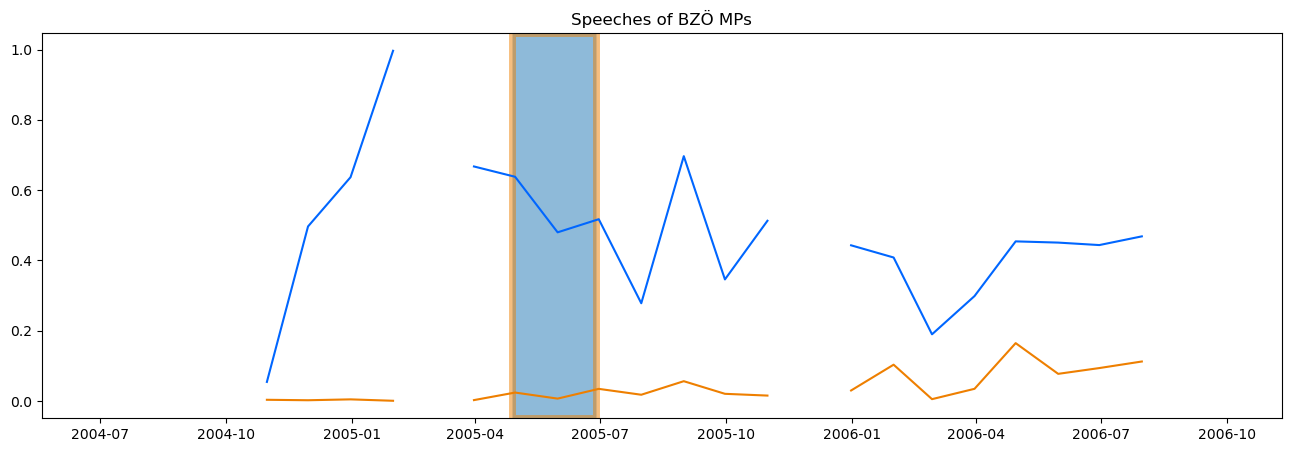

In [74]:
party1=2
party2=5
colour1=party_colour_dict.get(party1,'grey')
colour2=party_colour_dict.get(party2,'grey')
fig, ax = plt.subplots(figsize=(16, 5))
df5 = df2_B.resample('m').mean()
plt.plot(df5.index, df5[party1], color= colour1)
plt.plot(df5.index, df5[party2], color= colour2)
#smoothing the graph
    
plt.title('Speeches of BZÖ MPs')
plt.axvspan(datetime(2005,4,28), datetime(2005, 6, 28), alpha=0.5, edgecolor=colour2, linewidth=5)

In [48]:
def desc_timeperiod(df):
    print('shape of dataframe:{}'.format(df.shape))
    print('--------------------------------------------------')
    print('Number of MPs: {}'.format(df['speaker'].unique().shape))
    print('--------------------------------------------------')
    print('Unique parties:{}'.format(df['party'].unique()))
    print('--------------------------------------------------')
    print('Mean speech length: {}'.format(df['terms'].mean()))
    print('---------------------------------------------------')
    print('Number of speeches per party:\n{}'.format(df['party'].value_counts()))
    print('----------------------------------------------------')
    print('Average Number of speeches per MP:\n{}'.format(df['speaker'].value_counts().mean()))
    print('Lenght of period in months:{}'.format((df['date_format'].max()-df['date_format'].min())/np.timedelta64(1, 'M')))

In [49]:
for i in range(0,7):
    temp_df = df[df['gov']==i]
    desc_timeperiod(temp_df)

shape of dataframe:(15854, 10)
--------------------------------------------------
Number of MPs: (228,)
--------------------------------------------------
Unique parties:[0 1 2 4 3]
--------------------------------------------------
Mean speech length: 674.0272486438754
---------------------------------------------------
Number of speeches per party:
0    4279
2    3870
1    3834
3    1976
4    1895
Name: party, dtype: int64
----------------------------------------------------
Average Number of speeches per MP:
69.53508771929825
Lenght of period in months:41.988541859175754
shape of dataframe:(12129, 10)
--------------------------------------------------
Number of MPs: (223,)
--------------------------------------------------
Unique parties:[0 2 1 3]
--------------------------------------------------
Mean speech length: 606.336548767417
---------------------------------------------------
Number of speeches per party:
2    3443
0    3436
1    3091
3    2159
Name: party, dtype: int64
---

In [51]:
filename= "data/gov_data.xlsx"

df.to_excel(filename)

|          |    0 |    1 |    2 |    3 |    4 |    5 |   6 |
|:---------|-----:|-----:|-----:|-----:|-----:|-----:|----:|
| (0, 0.0) | 2857 | 2669 | 3172 | 1115 | 3059 | 2082 | 655 |
| (0, 1.0) |  955 |  239 |  311 |  518 | 1881 | 1279 |  71 |
| (0, 2.0) |  246 |  252 |  366 |  174 |  404 |  285 |  84 |
| (0, 3.0) |  100 |  247 |  447 |  122 |  236 |  171 |  84 |
| (0, 4.0) |  117 |   11 |    5 |    0 |    1 |    0 |   0 |
| (0, 5.0) |    2 |   17 |   67 |   41 |  138 |   37 |  25 |
| (0, 6.0) |    1 |    0 |    2 |    4 |   19 |   49 |  41 |
| (0, 7.0) |    1 |    1 |    6 |    3 |   14 |   27 |   8 |
| (0, 8.0) |    0 |    0 |    0 |    3 |    1 |    4 |  21 |
| (1, 0.0) | 1414 |  361 |  595 |  376 | 1044 |  677 | 169 |
| (1, 1.0) | 1979 | 1804 | 3533 | 1520 | 3569 | 2395 | 784 |
| (1, 2.0) |  270 |  862 |  676 |  212 |  510 |  244 | 110 |
| (1, 3.0) |   81 |   45 |   41 |   29 |  101 |   60 |  14 |
| (1, 4.0) |   82 |    4 |    1 |    0 |    0 |    2 |   0 |
| (1, 5.0) |    6 |   13 |   51 |   51 |  180 |   26 |   4 |
| (1, 6.0) |    2 |    2 |    2 |    7 |   11 |   36 |  16 |
| (1, 7.0) |    0 |    0 |    4 |    1 |   26 |   53 |   3 |
| (1, 8.0) |    0 |    0 |    0 |    1 |    1 |    1 |   2 |
| (2, 0.0) |  250 |  309 |  246 |  106 |  318 |  229 | 118 |
| (2, 1.0) |  235 |  955 |  639 |   62 |  218 |  194 | 301 |
| (2, 2.0) | 3049 | 2039 | 1184 |  683 | 2076 | 1702 | 491 |
| (2, 3.0) |  189 |   61 |   49 |   50 |  153 |  106 |  13 |
| (2, 4.0) |  139 |    7 |    0 |    1 |    2 |    0 |   0 |
| (2, 5.0) |    6 |   69 |  135 |  138 |  397 |  121 |   6 |
| (2, 6.0) |    1 |    3 |    2 |    2 |   15 |   57 |  11 |
| (2, 7.0) |    0 |    0 |    3 |    6 |   29 |  104 |  24 |
| (2, 8.0) |    1 |    0 |    0 |    0 |    0 |    4 |   0 |
| (3, 0.0) |  280 |  772 |  755 |  237 |  537 |  443 |   0 |
| (3, 1.0) |  114 |   73 |   70 |   34 |  138 |   99 |   0 |
| (3, 2.0) |  442 |  221 |  188 |   93 |  315 |  209 |   0 |
| (3, 3.0) |  804 | 1063 | 1437 |  597 | 1651 |  987 |   0 |
| (3, 4.0) |  328 |    5 |    1 |    0 |    2 |    0 |   0 |
| (3, 5.0) |    6 |   21 |   36 |   45 |  165 |   33 |   0 |
| (3, 6.0) |    2 |    3 |    8 |    2 |   34 |  136 |   0 |
| (3, 7.0) |    0 |    1 |    1 |    0 |   18 |   31 |   0 |
| (3, 8.0) |    0 |    0 |    0 |    0 |    5 |   13 |   0 |
| (4, 0.0) |  290 |    0 |   24 |    0 |    0 |    3 |   0 |
| (4, 1.0) |  155 |    0 |    1 |    0 |    0 |    5 |   0 |
| (4, 2.0) |  427 |    0 |    1 |    0 |    0 |    0 |   0 |
| (4, 3.0) |  321 |    0 |    4 |    0 |    0 |    0 |   0 |
| (4, 4.0) |  700 |    0 |    0 |    0 |    0 |    0 |   0 |
| (4, 5.0) |    2 |    0 |    0 |    0 |    0 |    0 |   0 |
| (4, 6.0) |    0 |    0 |    0 |    0 |    0 |    8 |   0 |
| (4, 8.0) |    0 |    0 |    0 |    0 |    0 |    1 |   0 |
| (5, 0.0) |    0 |    0 |   42 |   82 |  275 |    0 |   0 |
| (5, 1.0) |    0 |    0 |  125 |   99 |  152 |    0 |   0 |
| (5, 2.0) |    0 |    0 |  236 |  258 | 1166 |    0 |   0 |
| (5, 3.0) |    0 |    0 |    8 |   29 |  130 |    0 |   0 |
| (5, 4.0) |    0 |    0 |    1 |    0 |    2 |    0 |   0 |
| (5, 5.0) |    0 |    0 |   18 |  207 | 1161 |    0 |   0 |
| (5, 6.0) |    0 |    0 |    0 |    0 |   10 |    0 |   0 |
| (5, 7.0) |    0 |    0 |    1 |    3 |  165 |    0 |   0 |
| (6, 0.0) |    0 |    0 |    0 |    0 |    0 |  147 |  84 |
| (6, 1.0) |    0 |    0 |    0 |    0 |    0 |  111 |  41 |
| (6, 2.0) |    0 |    0 |    0 |    0 |    0 |  296 |  76 |
| (6, 3.0) |    0 |    0 |    0 |    0 |    0 |  268 |  69 |
| (6, 4.0) |    0 |    0 |    0 |    0 |    0 |    1 |   1 |
| (6, 5.0) |    0 |    0 |    0 |    0 |    0 |   37 |  10 |
| (6, 6.0) |    0 |    0 |    0 |    0 |    0 |  511 | 146 |
| (6, 7.0) |    0 |    0 |    0 |    0 |    0 |   34 |   5 |
| (6, 8.0) |    0 |    0 |    0 |    0 |    0 |    8 |  21 |
| (7, 0.0) |    0 |    0 |    0 |    0 |   14 |  107 |   0 |
| (7, 1.0) |    0 |    0 |    0 |    0 |   16 |  155 |   0 |
| (7, 2.0) |    0 |    0 |    0 |    0 |   64 |  518 |   0 |
| (7, 3.0) |    0 |    0 |    0 |    0 |    3 |   39 |   0 |
| (7, 4.0) |    0 |    0 |    0 |    0 |    0 |    2 |   0 |
| (7, 5.0) |    0 |    0 |    0 |    0 |  118 |  143 |   0 |
| (7, 6.0) |    0 |    0 |    0 |    0 |    2 |   18 |   0 |
| (7, 7.0) |    0 |    0 |    0 |    0 |   17 |  105 |   0 |
| (7, 8.0) |    0 |    0 |    0 |    0 |    1 |    0 |   0 |
| (8, 0.0) |    0 |    0 |    0 |    0 |    0 |    0 | 111 |
| (8, 1.0) |    0 |    0 |    0 |    0 |    0 |    0 |  26 |
| (8, 2.0) |    0 |    0 |    0 |    0 |    0 |    0 |  43 |
| (8, 3.0) |    0 |    0 |    0 |    0 |    0 |    0 | 111 |
| (8, 5.0) |    0 |    0 |    0 |    0 |    0 |    0 |   5 |
| (8, 6.0) |    0 |    0 |    0 |    0 |    0 |    0 |  34 |
| (8, 7.0) |    0 |    0 |    0 |    0 |    0 |    0 |  11 |
| (8, 8.0) |    0 |    0 |    0 |    0 |    0 |    0 |   5 |
| (9, 0.0) |   51 |    0 |    2 |    0 |    7 |   16 |   9 |
| (9, 0.2) |   27 |    0 |    4 |    0 |    2 |   19 |   9 |
| (9, 0.4) |   16 |    0 |    5 |    0 |    9 |   21 |  10 |
| (9, 0.6) |   22 |    0 |    4 |    0 |   13 |   27 |  13 |
| (9, 0.8) |   14 |    0 |    8 |    0 |   16 |   37 |  15 |
| (9, 1.0) |   23 |    0 |   51 |    0 |   29 |   58 |  61 |
| (9, 1.2) |    9 |    0 |   34 |    0 |   12 |   28 |  10 |
| (9, 1.4) |    9 |    0 |   19 |    0 |    9 |   17 |  10 |
| (9, 1.6) |    3 |    0 |   17 |    0 |    8 |   25 |   7 |
| (9, 1.8) |    0 |    0 |   11 |    0 |   10 |   28 |   8 |
| (9, 2.0) |    6 |    0 |   10 |    2 |   30 |  121 |   7 |
| (9, 2.2) |    0 |    0 |    0 |    0 |    3 |   16 |  11 |
| (9, 2.4) |    1 |    0 |    0 |    0 |    1 |    8 |   8 |
| (9, 2.6) |    2 |    0 |    0 |    1 |   17 |   22 |   2 |
| (9, 2.8) |    1 |    0 |    0 |    0 |    4 |    8 |   1 |
| (9, 3.0) |    1 |    0 |    0 |    0 |    7 |   34 |  11 |
| (9, 3.2) |    0 |    0 |    0 |    1 |   13 |   18 |   1 |
| (9, 3.4) |    1 |    0 |    0 |    0 |    4 |    2 |   2 |
| (9, 3.6) |    1 |    0 |    0 |    0 |    3 |   16 |   3 |
| (9, 3.8) |    0 |    0 |    0 |    1 |   14 |   12 |   0 |
| (9, 4.0) |    0 |    0 |    0 |    0 |    4 |   14 |   1 |
| (9, 4.2) |    0 |    0 |    0 |    0 |    1 |    7 |   4 |
| (9, 4.4) |    0 |    0 |    0 |    1 |   14 |   14 |   1 |
| (9, 4.6) |    0 |    0 |    0 |    0 |    1 |    3 |   0 |
| (9, 4.8) |    0 |    0 |    0 |    0 |    2 |    4 |   3 |
| (9, 5.0) |    0 |    0 |    0 |    0 |   28 |   12 |   2 |
| (9, 5.2) |    0 |    0 |    0 |    0 |    3 |    3 |   1 |
| (9, 5.4) |    0 |    0 |    0 |    0 |    3 |    5 |   0 |
| (9, 5.6) |    0 |    0 |    0 |    0 |    3 |   16 |   1 |
| (9, 5.8) |    0 |    0 |    0 |    0 |    2 |    4 |   2 |
| (9, 6.0) |    0 |    0 |    0 |    0 |   12 |   19 |   1 |
| (9, 6.2) |    0 |    0 |    0 |    0 |    3 |    5 |   0 |
| (9, 6.4) |    0 |    0 |    0 |    0 |    0 |    2 |   0 |
| (9, 6.6) |    0 |    0 |    0 |    0 |   15 |    7 |   1 |
| (9, 7.0) |    0 |    0 |    0 |    0 |   12 |   18 |   0 |
| (9, 7.6) |    0 |    0 |    0 |    0 |    0 |    0 |   2 |